# Fintech Liquidity Forecasting and Reserve Optimization

## Notebook 03 — Baselines and ETS

### Objective

The objective of this notebook is to establish reproducible forecasting
benchmarks and evaluate whether Exponential Smoothing models add predictive
value for daily Fintech cash outflows.

The primary forecasting target is:

$$
\text{total\_cash\_outflow}
=
\text{withdrawal\_amount}
+
\text{outgoing\_transfer\_amount}
$$

All forecasts will use a **28-day horizon** and will be evaluated using
time-ordered forecast origins. Training observations will always precede the
corresponding validation period.

### Models

The following benchmark models will be evaluated:

1. Naive.
2. Seasonal Naive with a seven-day period.
3. Moving Average.
4. Historical Weekday Average.

The Seasonal Naive model will be treated as the primary initial benchmark
because Notebook 02 identified a strong and stable weekly seasonal pattern.

A limited and justified set of ETS specifications will then be compared
against these benchmarks.

### Evaluation Principles

- No random train-test splits will be used.
- All comparable models will use the same forecast origins.
- Forecasts will be generated only from information available at each origin.
- Rolling averages and scaling terms will be calculated only from the
  corresponding training data.
- Model complexity must demonstrate consistent out-of-sample value.
- Results will be reported in ARS millions.

### Main Metrics

The initial comparison will include:

- Mean Absolute Error — MAE.
- Root Mean Squared Error — RMSE.
- Mean Absolute Scaled Error — MASE.
- Root Mean Squared Scaled Error — RMSSE.
- Mean Error — forecast bias.
- Error by forecast horizon.
- Stability across forecast origins.

### Expected Output

This notebook will produce:

1. Reproducible implementations of the four required benchmarks.
2. A common temporal backtesting design.
3. Validated forecast and metric tables.
4. A comparison of reasonable ETS specifications.
5. Residual diagnostics for the selected ETS model.
6. A documented decision about which models should continue to the final
   backtesting stage.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels
from statsmodels.tsa.holtwinters import ExponentialSmoothing


# ---------------------------------------------------------
# Resolve project paths
# ---------------------------------------------------------

CURRENT_DIR = Path.cwd()

PROJECT_ROOT = (
    CURRENT_DIR.parent
    if CURRENT_DIR.name == "notebooks"
    else CURRENT_DIR
)

DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"
MODELS_DIR = PROJECT_ROOT / "models"

for directory in [
    DATA_RAW_DIR,
    DATA_PROCESSED_DIR,
    FIGURES_DIR,
    MODELS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)


# ---------------------------------------------------------
# Output registry
# ---------------------------------------------------------

OUTPUT_REGISTRY = []


def register_output(
    file_path,
    output_type,
    rows=None,
    columns=None,
):
    """
    Register a generated notebook output.

    Existing entries with the same path are replaced so that rerunning
    a cell does not create duplicated registry records.
    """
    resolved_path = Path(file_path).resolve()

    OUTPUT_REGISTRY[:] = [
        record
        for record in OUTPUT_REGISTRY
        if record["path"] != str(resolved_path)
    ]

    OUTPUT_REGISTRY.append(
        {
            "output_type": output_type,
            "file_name": resolved_path.name,
            "path": str(resolved_path),
            "exists": resolved_path.exists(),
            "size_kb": round(
                resolved_path.stat().st_size / 1024,
                2,
            ),
            "rows": rows,
            "columns": columns,
        }
    )


def save_table(
    table,
    file_name,
    index=False,
):
    """
    Save a pandas table in data/processed and register the output.
    """
    if isinstance(table, pd.Series):
        table_to_save = table.reset_index()
    elif isinstance(table, pd.DataFrame):
        table_to_save = table.copy()
    else:
        raise TypeError(
            "table must be a pandas DataFrame or Series."
        )

    output_path = DATA_PROCESSED_DIR / file_name

    table_to_save.to_csv(
        output_path,
        index=index,
        date_format="%Y-%m-%d",
    )

    if not output_path.exists():
        raise FileNotFoundError(
            f"The table was not saved: {output_path}"
        )

    register_output(
        file_path=output_path,
        output_type="table",
        rows=len(table_to_save),
        columns=len(table_to_save.columns),
    )

    print(f"Table saved at: {output_path.resolve()}")

    return output_path


def save_figure(
    fig,
    file_name,
):
    """
    Save a matplotlib figure in figures and register the output.
    """
    output_path = FIGURES_DIR / file_name

    fig.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    if not output_path.exists():
        raise FileNotFoundError(
            f"The figure was not saved: {output_path}"
        )

    register_output(
        file_path=output_path,
        output_type="figure",
    )

    print(f"Figure saved at: {output_path.resolve()}")

    return output_path


print(f"Project root: {PROJECT_ROOT.resolve()}")
print(f"statsmodels version: {statsmodels.__version__}")

Project root: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting
statsmodels version: 0.14.6


In [2]:
# ---------------------------------------------------------
# Notebook configuration
# ---------------------------------------------------------

DATA_PATH = (
    DATA_RAW_DIR
    / "synthetic_fintech_daily.csv"
)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "The synthetic daily dataset was not found at:\n"
        f"{DATA_PATH.resolve()}\n\n"
        "Run Notebook 01 before continuing."
    )

TARGET = "total_cash_outflow"
DATE_COLUMN = "date"

FORECAST_HORIZON = 28
SEASONAL_PERIOD = 7
MONETARY_UNIT = "ARS million"

NOTEBOOK_CONFIG = {
    "input_file": DATA_PATH.name,
    "target": TARGET,
    "date_column": DATE_COLUMN,
    "forecast_horizon_days": FORECAST_HORIZON,
    "seasonal_period_days": SEASONAL_PERIOD,
    "primary_benchmark": "seasonal_naive_7",
    "monetary_unit": MONETARY_UNIT,
    "random_split_allowed": False,
}


# ---------------------------------------------------------
# Load dataset
# ---------------------------------------------------------

df = pd.read_csv(
    DATA_PATH,
    parse_dates=[DATE_COLUMN],
)

df = (
    df.sort_values(DATE_COLUMN)
    .reset_index(drop=True)
)

notebook_configuration = (
    pd.Series(
        NOTEBOOK_CONFIG,
        name="value",
    )
    .rename_axis("parameter")
    .reset_index()
)

save_table(
    notebook_configuration,
    "03_notebook_configuration.csv",
)

print(f"Dataset shape: {df.shape}")

notebook_configuration

Table saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\03_notebook_configuration.csv
Dataset shape: (1308, 39)


,parameter,value
0,input_file,synthetic_fintech_daily.csv
1,target,total_cash_outflow
2,date_column,date
3,forecast_horizon_days,28
4,seasonal_period_days,7
5,primary_benchmark,seasonal_naive_7
6,monetary_unit,ARS million
7,random_split_allowed,False


In [3]:
# ---------------------------------------------------------
# Initial dataset-integrity checks
# ---------------------------------------------------------

expected_dates = pd.date_range(
    start=df[DATE_COLUMN].min(),
    end=df[DATE_COLUMN].max(),
    freq="D",
)

numeric_columns = (
    df.select_dtypes(include=[np.number])
    .columns
    .tolist()
)

date_gaps = (
    df[DATE_COLUMN]
    .diff()
    .dropna()
    .dt.days
)

initial_data_checks = pd.Series(
    {
        "number_of_rows": len(df),
        "number_of_columns": len(df.columns),

        "start_date": df[DATE_COLUMN].min(),
        "end_date": df[DATE_COLUMN].max(),

        "duplicated_dates": int(
            df[DATE_COLUMN]
            .duplicated()
            .sum()
        ),

        "missing_dates": len(
            expected_dates.difference(
                df[DATE_COLUMN]
            )
        ),

        "non_daily_date_gaps": int(
            date_gaps.ne(1).sum()
        ),

        "missing_values": int(
            df.isna().sum().sum()
        ),

        "infinite_numeric_values": int(
            (
                ~np.isfinite(
                    df[numeric_columns]
                    .to_numpy(dtype=float)
                )
            ).sum()
        ),

        "non_positive_target_values": int(
            df[TARGET].le(0).sum()
        ),

        "target_minimum": round(
            df[TARGET].min(),
            3,
        ),

        "target_median": round(
            df[TARGET].median(),
            3,
        ),

        "target_mean": round(
            df[TARGET].mean(),
            3,
        ),

        "target_maximum": round(
            df[TARGET].max(),
            3,
        ),
    },
    name="value",
).rename_axis("check").reset_index()

save_table(
    initial_data_checks,
    "03_initial_data_checks.csv",
)

initial_data_checks

Table saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\03_initial_data_checks.csv


,check,value
0,number_of_rows,1308
1,number_of_columns,39
2,start_date,2023-01-01 00:00:00
3,end_date,2026-07-31 00:00:00
4,duplicated_dates,0
5,missing_dates,0
6,non_daily_date_gaps,0
7,missing_values,0
8,infinite_numeric_values,0
9,non_positive_target_values,0


In [4]:
# Stop execution if the input differs from the dataset
# validated in Notebooks 01 and 02.

assert df.shape == (1308, 39), (
    "The input dataset shape is not the expected shape."
)

assert df[DATE_COLUMN].duplicated().sum() == 0, (
    "Duplicated dates were detected."
)

assert len(
    expected_dates.difference(
        df[DATE_COLUMN]
    )
) == 0, (
    "Missing dates were detected."
)

assert date_gaps.eq(1).all(), (
    "The dataset does not have a continuous daily frequency."
)

assert df.isna().sum().sum() == 0, (
    "Missing values were detected."
)

assert np.isfinite(
    df[numeric_columns]
    .to_numpy(dtype=float)
).all(), (
    "Infinite numeric values were detected."
)

assert df[TARGET].gt(0).all(), (
    "Non-positive target values were detected."
)

assert FORECAST_HORIZON == 28
assert SEASONAL_PERIOD == 7

print("Notebook 03 input validation passed successfully.")

Notebook 03 input validation passed successfully.


## Temporal Backtesting Design

All benchmark and ETS models will be evaluated using the same expanding-window
backtesting design.

For each fold:

- The training set contains all observations available up to the forecast
  origin.
- The following 28 days form the test set.
- The training window expands as the forecast origin moves forward.
- Test windows do not overlap.
- No future observations are used to generate forecasts or calculate
  training-dependent metrics.

The minimum requested training history is 728 days, equivalent to 104 weeks.
Forecast origins are aligned backward from the end of the dataset so that the
last 28-day test window ends exactly on July 31, 2026.

This design provides repeated out-of-sample evaluation while preserving the
temporal order of the series.

In [5]:
# ---------------------------------------------------------
# Common temporal backtesting design
# ---------------------------------------------------------

MIN_TRAINING_DAYS = 728
BACKTEST_STEP_DAYS = 28

if MIN_TRAINING_DAYS < 2 * SEASONAL_PERIOD:
    raise ValueError(
        "The minimum training period is too short "
        "for weekly seasonal evaluation."
    )

if BACKTEST_STEP_DAYS <= 0:
    raise ValueError(
        "BACKTEST_STEP_DAYS must be positive."
    )

if FORECAST_HORIZON <= 0:
    raise ValueError(
        "FORECAST_HORIZON must be positive."
    )


# The last test window ends exactly on the final dataset date.
last_test_start_position = (
    len(df) - FORECAST_HORIZON
)

if last_test_start_position < MIN_TRAINING_DAYS:
    raise ValueError(
        "The dataset is too short for the requested "
        "training period and forecast horizon."
    )


# Generate test starts backward from the end of the dataset.
# Sorting restores chronological fold order.
test_start_positions = sorted(
    range(
        last_test_start_position,
        MIN_TRAINING_DAYS - 1,
        -BACKTEST_STEP_DAYS,
    )
)

fold_rows = []

for fold_number, test_start_position in enumerate(
    test_start_positions,
    start=1,
):
    train_start_position = 0
    train_end_position = test_start_position - 1
    test_end_position = (
        test_start_position
        + FORECAST_HORIZON
        - 1
    )

    fold_rows.append(
        {
            "fold_id": f"fold_{fold_number:02d}",
            "train_start": df.loc[
                train_start_position,
                DATE_COLUMN,
            ],
            "train_end": df.loc[
                train_end_position,
                DATE_COLUMN,
            ],
            "forecast_origin": df.loc[
                train_end_position,
                DATE_COLUMN,
            ],
            "test_start": df.loc[
                test_start_position,
                DATE_COLUMN,
            ],
            "test_end": df.loc[
                test_end_position,
                DATE_COLUMN,
            ],
            "train_start_position": (
                train_start_position
            ),
            "train_end_position": (
                train_end_position
            ),
            "test_start_position": (
                test_start_position
            ),
            "test_end_position": (
                test_end_position
            ),
            "train_size": (
                train_end_position
                - train_start_position
                + 1
            ),
            "test_size": (
                test_end_position
                - test_start_position
                + 1
            ),
            "forecast_horizon_days": (
                FORECAST_HORIZON
            ),
        }
    )

backtest_folds = pd.DataFrame(fold_rows)


# ---------------------------------------------------------
# Validate overlap between consecutive test windows
# ---------------------------------------------------------

test_window_overlap_days = []

for previous_index, current_index in zip(
    backtest_folds.index[:-1],
    backtest_folds.index[1:],
):
    previous_test_end = backtest_folds.loc[
        previous_index,
        "test_end",
    ]

    current_test_start = backtest_folds.loc[
        current_index,
        "test_start",
    ]

    overlap_days = max(
        0,
        (
            previous_test_end
            - current_test_start
        ).days
        + 1,
    )

    test_window_overlap_days.append(
        overlap_days
    )


# ---------------------------------------------------------
# Backtest design summary
# ---------------------------------------------------------

backtest_design_summary = pd.Series(
    {
        "number_of_folds": len(
            backtest_folds
        ),

        "minimum_training_days_requested": (
            MIN_TRAINING_DAYS
        ),

        "first_fold_training_days": int(
            backtest_folds[
                "train_size"
            ].iloc[0]
        ),

        "last_fold_training_days": int(
            backtest_folds[
                "train_size"
            ].iloc[-1]
        ),

        "forecast_horizon_days": (
            FORECAST_HORIZON
        ),

        "step_between_origins_days": (
            BACKTEST_STEP_DAYS
        ),

        "first_forecast_origin": (
            backtest_folds[
                "forecast_origin"
            ].iloc[0]
        ),

        "last_forecast_origin": (
            backtest_folds[
                "forecast_origin"
            ].iloc[-1]
        ),

        "first_test_start": (
            backtest_folds[
                "test_start"
            ].iloc[0]
        ),

        "last_test_end": (
            backtest_folds[
                "test_end"
            ].iloc[-1]
        ),

        "maximum_test_window_overlap_days": (
            max(
                test_window_overlap_days,
                default=0,
            )
        ),

        "expanding_training_window": True,
    },
    name="value",
).rename_axis("parameter").reset_index()


# ---------------------------------------------------------
# Save outputs
# ---------------------------------------------------------

save_table(
    backtest_folds,
    "03_backtest_folds.csv",
)

save_table(
    backtest_design_summary,
    "03_backtest_design_summary.csv",
)

display(backtest_design_summary)
display(backtest_folds)

Table saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\03_backtest_folds.csv
Table saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\03_backtest_design_summary.csv


,parameter,value
0,number_of_folds,20
1,minimum_training_days_requested,728
2,first_fold_training_days,748
3,last_fold_training_days,1280
4,forecast_horizon_days,28
5,step_between_origins_days,28
6,first_forecast_origin,2025-01-17 00:00:00
7,last_forecast_origin,2026-07-03 00:00:00
8,first_test_start,2025-01-18 00:00:00
9,last_test_end,2026-07-31 00:00:00


,fold_id,train_start,train_end,forecast_origin,test_start,test_end,train_start_position,train_end_position,test_start_position,test_end_position,train_size,test_size,forecast_horizon_days
0,fold_01,2023-01-01,2025-01-17,2025-01-17,2025-01-18,2025-02-14,0,747,748,775,748,28,28
1,fold_02,2023-01-01,2025-02-14,2025-02-14,2025-02-15,2025-03-14,0,775,776,803,776,28,28
2,fold_03,2023-01-01,2025-03-14,2025-03-14,2025-03-15,2025-04-11,0,803,804,831,804,28,28
3,fold_04,2023-01-01,2025-04-11,2025-04-11,2025-04-12,2025-05-09,0,831,832,859,832,28,28
4,fold_05,2023-01-01,2025-05-09,2025-05-09,2025-05-10,2025-06-06,0,859,860,887,860,28,28
5,fold_06,2023-01-01,2025-06-06,2025-06-06,2025-06-07,2025-07-04,0,887,888,915,888,28,28
6,fold_07,2023-01-01,2025-07-04,2025-07-04,2025-07-05,2025-08-01,0,915,916,943,916,28,28
7,fold_08,2023-01-01,2025-08-01,2025-08-01,2025-08-02,2025-08-29,0,943,944,971,944,28,28
8,fold_09,2023-01-01,2025-08-29,2025-08-29,2025-08-30,2025-09-26,0,971,972,999,972,28,28
9,fold_10,2023-01-01,2025-09-26,2025-09-26,2025-09-27,2025-10-24,0,999,1000,1027,1000,28,28


In [6]:
# ---------------------------------------------------------
# Backtest-design assertions
# ---------------------------------------------------------

assert len(backtest_folds) > 1, (
    "The backtest must contain multiple forecast origins."
)

assert (
    backtest_folds["train_size"]
    .ge(MIN_TRAINING_DAYS)
    .all()
), (
    "At least one fold has insufficient training history."
)

assert (
    backtest_folds["test_size"]
    .eq(FORECAST_HORIZON)
    .all()
), (
    "At least one fold has an incorrect test-window size."
)

assert (
    backtest_folds["train_end"]
    < backtest_folds["test_start"]
).all(), (
    "Training and test periods overlap."
)

assert (
    backtest_folds["forecast_origin"]
    == backtest_folds["train_end"]
).all(), (
    "Forecast origins do not match training-end dates."
)

assert (
    backtest_folds["test_start"]
    - backtest_folds["forecast_origin"]
).dt.days.eq(1).all(), (
    "Test windows do not begin immediately after the forecast origin."
)

assert (
    backtest_folds["test_end"]
    - backtest_folds["test_start"]
).dt.days.add(1).eq(
    FORECAST_HORIZON
).all(), (
    "At least one test window does not contain 28 days."
)

assert backtest_folds[
    "train_size"
].is_monotonic_increasing, (
    "Training windows are not expanding."
)

assert max(
    test_window_overlap_days,
    default=0,
) == 0, (
    "Test windows unexpectedly overlap."
)

assert (
    backtest_folds["test_end"].iloc[-1]
    == df[DATE_COLUMN].max()
), (
    "The final test window does not end on the last dataset date."
)

print(
    "Temporal backtesting design validation "
    "passed successfully."
)

Temporal backtesting design validation passed successfully.


Figure saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\figures\03_temporal_backtesting_design.png


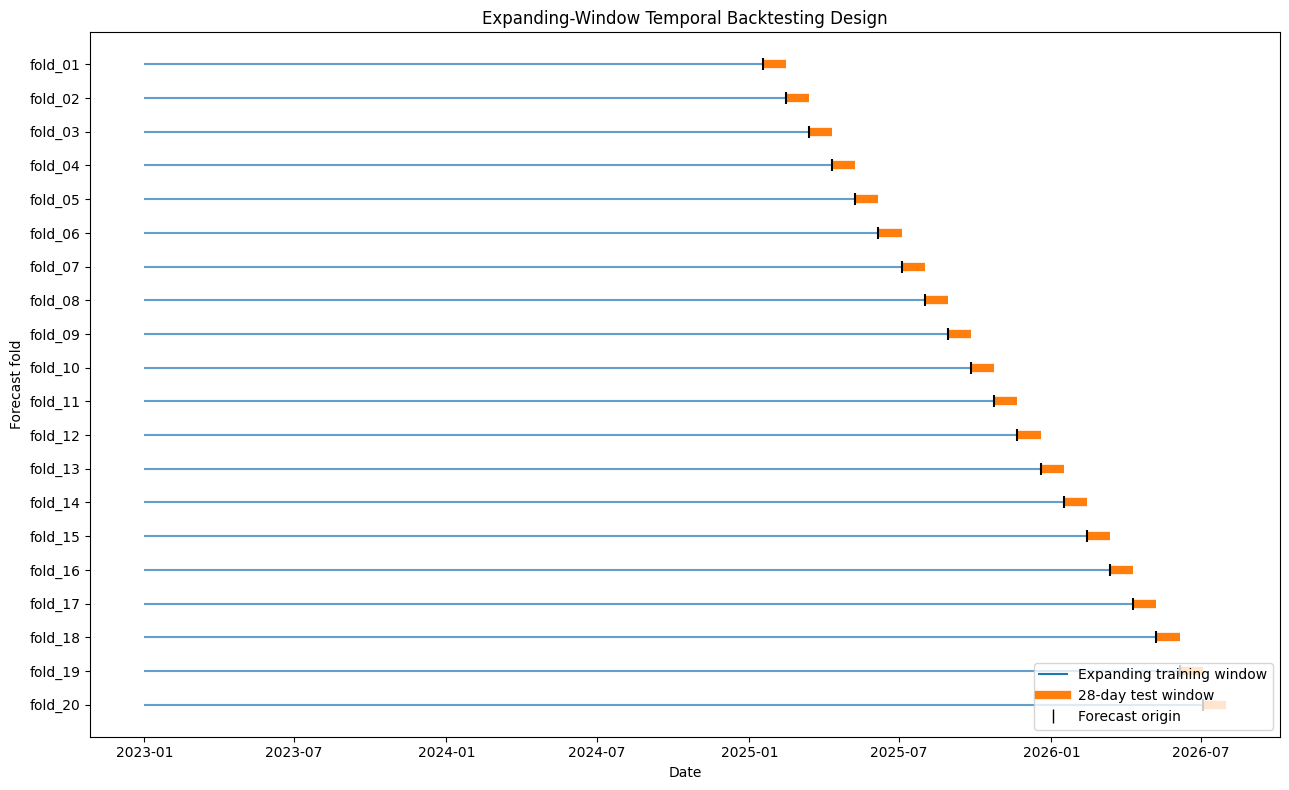

In [8]:
from matplotlib.lines import Line2D

# ---------------------------------------------------------
# Visualize and save the temporal backtesting design
# ---------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(13, 8)
)

for row_number, fold in backtest_folds.iterrows():
    y_position = row_number + 1

    ax.hlines(
        y=y_position,
        xmin=fold["train_start"],
        xmax=fold["train_end"],
        linewidth=1.5,
        alpha=0.70,
        color="tab:blue",
    )

    ax.hlines(
        y=y_position,
        xmin=fold["test_start"],
        xmax=fold["test_end"],
        linewidth=6,
        color="tab:orange",
    )

    ax.scatter(
        fold["forecast_origin"],
        y_position,
        marker="|",
        s=80,
        color="black",
        zorder=3,
    )

ax.set_title(
    "Expanding-Window Temporal Backtesting Design"
)

ax.set_xlabel("Date")
ax.set_ylabel("Forecast fold")

ax.set_yticks(
    range(
        1,
        len(backtest_folds) + 1,
    )
)

ax.set_yticklabels(
    backtest_folds["fold_id"]
)

ax.invert_yaxis()

legend_elements = [
    Line2D(
        [0],
        [0],
        color="tab:blue",
        linewidth=1.5,
        label="Expanding training window",
    ),
    Line2D(
        [0],
        [0],
        color="tab:orange",
        linewidth=6,
        label="28-day test window",
    ),
    Line2D(
        [0],
        [0],
        color="black",
        marker="|",
        linestyle="None",
        markersize=10,
        label="Forecast origin",
    ),
]

ax.legend(
    handles=legend_elements,
    loc="lower right",
)

fig.tight_layout()

save_figure(
    fig,
    "03_temporal_backtesting_design.png",
)

plt.show()

## Benchmark Forecasting Models

Four simple and reproducible benchmark models are evaluated before introducing
ETS or other statistical models.

### Naive

All future observations are forecast using the last value available at the
forecast origin:

$$
\hat{y}_{t+h|t}
=
y_t
$$

### Seasonal Naive

Each future observation is forecast using the most recent value from the same
day of the weekly cycle:

$$
\hat{y}_{t+h|t}
=
y_{t+h-7k}
$$

where the selected historical observation is the latest available value with
the same weekly seasonal position.

This is the primary benchmark because Notebook 02 validated a strong
seven-day seasonal pattern.

### Moving Average

All future observations are forecast using the mean of the last 28 available
daily observations:

$$
\hat{y}_{t+h|t}
=
\frac{1}{28}
\sum_{i=0}^{27} y_{t-i}
$$

### Historical Weekday Average

Each target date is forecast using the mean of the last eight observations
available for the same day of the week.

For example, a future Monday is forecast using the last eight Mondays in the
training set.

All benchmark calculations use training data only. No values from the
28-day test window are used to construct a forecast.

In [9]:
# ---------------------------------------------------------
# Benchmark model definitions
# ---------------------------------------------------------

MOVING_AVERAGE_WINDOW = 28
WEEKDAY_HISTORY_OCCURRENCES = 8

benchmark_definitions = pd.DataFrame(
    [
        {
            "model_name": "naive",
            "description": (
                "Repeat the last observed target value "
                "for all forecast horizons."
            ),
            "main_parameter": "none",
            "uses_training_data_only": True,
        },
        {
            "model_name": "seasonal_naive_7",
            "description": (
                "Repeat the latest complete seven-day "
                "target pattern."
            ),
            "main_parameter": (
                f"seasonal_period={SEASONAL_PERIOD}"
            ),
            "uses_training_data_only": True,
        },
        {
            "model_name": "moving_average_28",
            "description": (
                "Repeat the trailing mean of the last "
                "28 training observations."
            ),
            "main_parameter": (
                f"window={MOVING_AVERAGE_WINDOW}"
            ),
            "uses_training_data_only": True,
        },
        {
            "model_name": "historical_weekday_average",
            "description": (
                "Forecast each weekday using the mean "
                "of its last eight training observations."
            ),
            "main_parameter": (
                "weekday_occurrences="
                f"{WEEKDAY_HISTORY_OCCURRENCES}"
            ),
            "uses_training_data_only": True,
        },
    ]
)

save_table(
    benchmark_definitions,
    "03_benchmark_definitions.csv",
)

benchmark_definitions

Table saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\03_benchmark_definitions.csv


,model_name,description,main_parameter,uses_training_data_only
0,naive,Repeat the last observed target value for all ...,none,True
1,seasonal_naive_7,Repeat the latest complete seven-day target pa...,seasonal_period=7,True
2,moving_average_28,Repeat the trailing mean of the last 28 traini...,window=28,True
3,historical_weekday_average,Forecast each weekday using the mean of its la...,weekday_occurrences=8,True


In [15]:
def forecast_naive(
    training_values,
    forecast_horizon,
):
    """
    Repeat the final observed value for every future horizon.
    """
    values = np.asarray(
        training_values,
        dtype=float,
    )

    if len(values) == 0:
        raise ValueError(
            "The training series is empty."
        )

    return np.repeat(
        values[-1],
        forecast_horizon,
    )


def forecast_seasonal_naive(
    training_values,
    forecast_horizon,
    seasonal_period=7,
):
    """
    Repeat the latest complete seasonal pattern.
    """
    values = np.asarray(
        training_values,
        dtype=float,
    )

    if len(values) < seasonal_period:
        raise ValueError(
            "The training series is shorter than "
            "the seasonal period."
        )

    latest_pattern = values[
        -seasonal_period:
    ]

    return np.resize(
        latest_pattern,
        forecast_horizon,
    )


def forecast_moving_average(
    training_values,
    forecast_horizon,
    window=28,
):
    """
    Repeat the trailing training mean for every horizon.
    """
    values = np.asarray(
        training_values,
        dtype=float,
    )

    if len(values) < window:
        raise ValueError(
            "The training series is shorter than "
            "the moving-average window."
        )

    trailing_mean = values[
        -window:
    ].mean()

    return np.repeat(
        trailing_mean,
        forecast_horizon,
    )


def forecast_historical_weekday_average(
    training_data,
    future_dates,
    target_column,
    date_column,
    weekday_occurrences=8,
):
    """
    Forecast each target date using the most recent observations
    available for the same day of the week.
    """
    training_frame = (
        training_data[
            [date_column, target_column]
        ]
        .copy()
        .sort_values(date_column)
    )

    training_frame["day_of_week"] = (
        training_frame[date_column]
        .dt.dayofweek
    )

    forecasts = []

    for future_date in pd.DatetimeIndex(
        future_dates
    ):
        future_day_of_week = (
            future_date.dayofweek
        )

        comparable_values = (
            training_frame.loc[
                training_frame[
                    "day_of_week"
                ].eq(future_day_of_week),
                target_column,
            ]
            .tail(weekday_occurrences)
        )

        if comparable_values.empty:
            raise ValueError(
                "No historical observations were found "
                f"for weekday {future_day_of_week}."
            )

        forecasts.append(
            comparable_values.mean()
        )

    return np.asarray(
        forecasts,
        dtype=float,
    )

In [16]:
# ---------------------------------------------------------
# Generate benchmark forecasts for every temporal fold
# ---------------------------------------------------------

benchmark_forecast_frames = []

for fold in backtest_folds.itertuples(
    index=False
):
    training_data = (
        df.iloc[
            fold.train_start_position:
            fold.train_end_position + 1
        ]
        .copy()
    )

    test_data = (
        df.iloc[
            fold.test_start_position:
            fold.test_end_position + 1
        ]
        .copy()
    )

    training_values = (
        training_data[TARGET]
        .to_numpy(dtype=float)
    )

    future_dates = (
        test_data[DATE_COLUMN]
        .to_numpy()
    )

    model_forecasts = {
        "naive": forecast_naive(
            training_values=training_values,
            forecast_horizon=FORECAST_HORIZON,
        ),

        "seasonal_naive_7": (
            forecast_seasonal_naive(
                training_values=training_values,
                forecast_horizon=FORECAST_HORIZON,
                seasonal_period=SEASONAL_PERIOD,
            )
        ),

        "moving_average_28": (
            forecast_moving_average(
                training_values=training_values,
                forecast_horizon=FORECAST_HORIZON,
                window=MOVING_AVERAGE_WINDOW,
            )
        ),

        "historical_weekday_average": (
            forecast_historical_weekday_average(
                training_data=training_data,
                future_dates=future_dates,
                target_column=TARGET,
                date_column=DATE_COLUMN,
                weekday_occurrences=(
                    WEEKDAY_HISTORY_OCCURRENCES
                ),
            )
        ),
    }

    for model_name, predictions in (
        model_forecasts.items()
    ):
        if len(predictions) != FORECAST_HORIZON:
            raise ValueError(
                f"{model_name} returned an incorrect "
                f"number of predictions in {fold.fold_id}."
            )

        forecast_frame = pd.DataFrame(
            {
                "fold_id": fold.fold_id,
                "model_name": model_name,
                "forecast_origin": (
                    fold.forecast_origin
                ),
                "target_date": (
                    test_data[DATE_COLUMN]
                    .to_numpy()
                ),
                "forecast_horizon": np.arange(
                    1,
                    FORECAST_HORIZON + 1,
                ),
                "actual": (
                    test_data[TARGET]
                    .to_numpy(dtype=float)
                ),
                "prediction": predictions,
            }
        )

        forecast_frame["error"] = (
            forecast_frame["prediction"]
            - forecast_frame["actual"]
        )

        forecast_frame["absolute_error"] = (
            forecast_frame["error"].abs()
        )

        forecast_frame["squared_error"] = (
            forecast_frame["error"] ** 2
        )

        benchmark_forecast_frames.append(
            forecast_frame
        )


benchmark_forecasts = pd.concat(
    benchmark_forecast_frames,
    ignore_index=True,
)

benchmark_forecasts = (
    benchmark_forecasts.sort_values(
        [
            "fold_id",
            "model_name",
            "forecast_horizon",
        ]
    )
    .reset_index(drop=True)
)

save_table(
    benchmark_forecasts,
    "03_benchmark_forecasts.csv",
)

print(
    "Benchmark forecast table shape: "
    f"{benchmark_forecasts.shape}"
)

benchmark_forecasts.head(12)

Table saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\03_benchmark_forecasts.csv
Benchmark forecast table shape: (2240, 10)


,fold_id,model_name,forecast_origin,target_date,forecast_horizon,actual,prediction,error,absolute_error,squared_error
0,fold_01,historical_weekday_average,2025-01-17,2025-01-18,1,692.977,584.879625,-108.097375,108.097375,11685.042482
1,fold_01,historical_weekday_average,2025-01-17,2025-01-19,2,468.426,433.862250,-34.563750,34.563750,1194.652814
2,fold_01,historical_weekday_average,2025-01-17,2025-01-20,3,774.585,803.501375,28.916375,28.916375,836.156743
3,fold_01,historical_weekday_average,2025-01-17,2025-01-21,4,758.083,813.480000,55.397000,55.397000,3068.827609
4,fold_01,historical_weekday_average,2025-01-17,2025-01-22,5,721.854,750.236750,28.382750,28.382750,805.580498
5,fold_01,historical_weekday_average,2025-01-17,2025-01-23,6,569.272,780.117125,210.845125,210.845125,44455.666736
6,fold_01,historical_weekday_average,2025-01-17,2025-01-24,7,797.000,783.656750,-13.343250,13.343250,178.042321
7,fold_01,historical_weekday_average,2025-01-17,2025-01-25,8,677.168,584.879625,-92.288375,92.288375,8517.144160
8,fold_01,historical_weekday_average,2025-01-17,2025-01-26,9,483.938,433.862250,-50.075750,50.075750,2507.580738
9,fold_01,historical_weekday_average,2025-01-17,2025-01-27,10,788.197,803.501375,15.304375,15.304375,234.223894


In [12]:
# ---------------------------------------------------------
# Validate benchmark forecast output
# ---------------------------------------------------------

benchmark_model_names = (
    benchmark_definitions[
        "model_name"
    ]
    .tolist()
)

expected_forecast_rows = (
    len(backtest_folds)
    * len(benchmark_model_names)
    * FORECAST_HORIZON
)

forecast_group_sizes = (
    benchmark_forecasts
    .groupby(
        [
            "fold_id",
            "model_name",
        ]
    )
    .size()
)

forecast_horizon_coverage = (
    benchmark_forecasts
    .groupby(
        [
            "fold_id",
            "model_name",
        ]
    )["forecast_horizon"]
    .agg(["min", "max", "nunique"])
)

benchmark_forecast_checks = pd.Series(
    {
        "expected_rows": (
            expected_forecast_rows
        ),

        "generated_rows": len(
            benchmark_forecasts
        ),

        "number_of_folds": (
            benchmark_forecasts[
                "fold_id"
            ].nunique()
        ),

        "number_of_models": (
            benchmark_forecasts[
                "model_name"
            ].nunique()
        ),

        "duplicated_forecast_rows": int(
            benchmark_forecasts
            .duplicated(
                subset=[
                    "fold_id",
                    "model_name",
                    "target_date",
                ]
            )
            .sum()
        ),

        "missing_values": int(
            benchmark_forecasts
            .isna()
            .sum()
            .sum()
        ),

        "infinite_predictions": int(
            (
                ~np.isfinite(
                    benchmark_forecasts[
                        "prediction"
                    ]
                )
            )
            .sum()
        ),

        "non_positive_predictions": int(
            benchmark_forecasts[
                "prediction"
            ]
            .le(0)
            .sum()
        ),

        "incorrect_group_sizes": int(
            forecast_group_sizes
            .ne(FORECAST_HORIZON)
            .sum()
        ),

        "incorrect_minimum_horizon": int(
            forecast_horizon_coverage[
                "min"
            ]
            .ne(1)
            .sum()
        ),

        "incorrect_maximum_horizon": int(
            forecast_horizon_coverage[
                "max"
            ]
            .ne(FORECAST_HORIZON)
            .sum()
        ),

        "incorrect_unique_horizons": int(
            forecast_horizon_coverage[
                "nunique"
            ]
            .ne(FORECAST_HORIZON)
            .sum()
        ),
    },
    name="value",
).rename_axis("check").reset_index()

save_table(
    benchmark_forecast_checks,
    "03_benchmark_forecast_checks.csv",
)

benchmark_forecast_checks

Table saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\03_benchmark_forecast_checks.csv


,check,value
0,expected_rows,2240
1,generated_rows,2240
2,number_of_folds,20
3,number_of_models,4
4,duplicated_forecast_rows,0
5,missing_values,0
6,infinite_predictions,0
7,non_positive_predictions,0
8,incorrect_group_sizes,0
9,incorrect_minimum_horizon,0


In [13]:
assert len(
    benchmark_forecasts
) == expected_forecast_rows, (
    "The benchmark forecast table has an incorrect number of rows."
)

assert (
    benchmark_forecasts[
        "fold_id"
    ].nunique()
    == len(backtest_folds)
), (
    "Not all folds are present in the forecast table."
)

assert (
    set(
        benchmark_forecasts[
            "model_name"
        ].unique()
    )
    == set(benchmark_model_names)
), (
    "The forecast table does not contain the expected models."
)

assert (
    benchmark_forecasts
    .duplicated(
        subset=[
            "fold_id",
            "model_name",
            "target_date",
        ]
    )
    .sum()
    == 0
), (
    "Duplicated benchmark forecasts were detected."
)

assert benchmark_forecasts.isna().sum().sum() == 0, (
    "Missing benchmark forecast values were detected."
)

assert np.isfinite(
    benchmark_forecasts[
        [
            "actual",
            "prediction",
            "error",
            "absolute_error",
            "squared_error",
        ]
    ]
    .to_numpy(dtype=float)
).all(), (
    "Infinite benchmark forecast values were detected."
)

assert benchmark_forecasts[
    "prediction"
].gt(0).all(), (
    "Non-positive benchmark predictions were detected."
)

assert forecast_group_sizes.eq(
    FORECAST_HORIZON
).all(), (
    "At least one model-fold group does not contain 28 forecasts."
)

print(
    "Benchmark forecast generation validation "
    "passed successfully."
)

Benchmark forecast generation validation passed successfully.


Figure saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\figures\03_benchmark_forecasts_last_fold.png


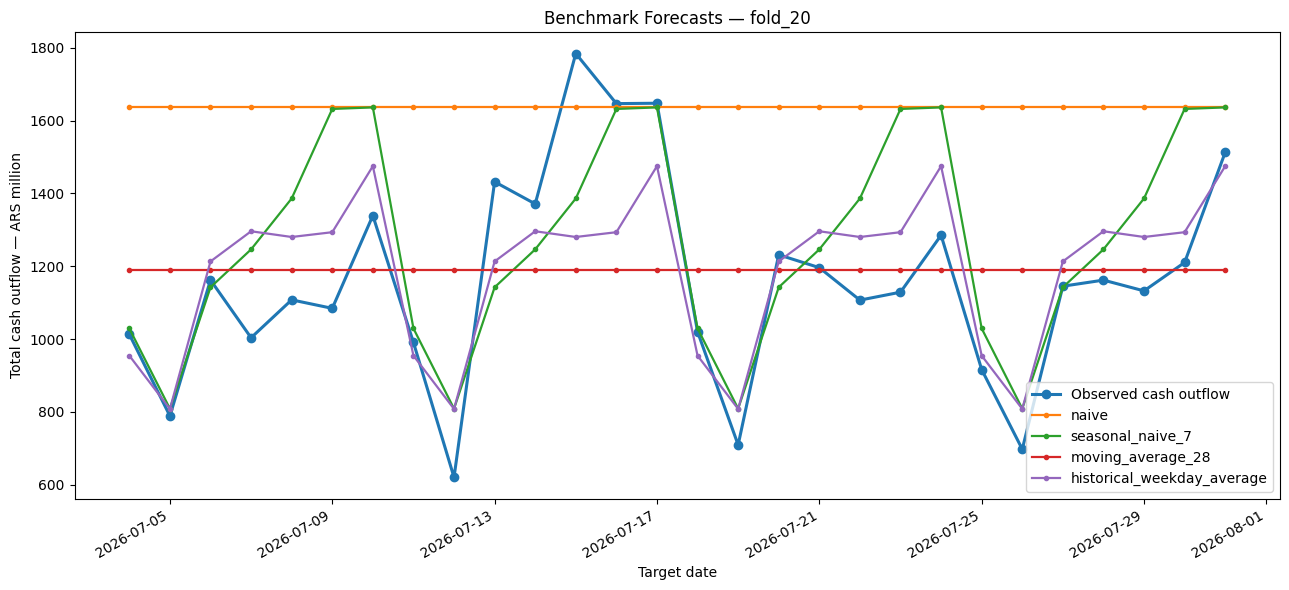

In [14]:
# ---------------------------------------------------------
# Compare benchmark forecasts in the final temporal fold
# ---------------------------------------------------------

selected_fold_id = (
    backtest_folds[
        "fold_id"
    ].iloc[-1]
)

selected_fold_forecasts = (
    benchmark_forecasts.loc[
        benchmark_forecasts[
            "fold_id"
        ].eq(selected_fold_id)
    ]
    .copy()
)

selected_fold_actual = (
    selected_fold_forecasts[
        [
            "target_date",
            "actual",
        ]
    ]
    .drop_duplicates()
    .sort_values("target_date")
)

fig, ax = plt.subplots(
    figsize=(13, 6)
)

ax.plot(
    selected_fold_actual[
        "target_date"
    ],
    selected_fold_actual[
        "actual"
    ],
    marker="o",
    linewidth=2.2,
    label="Observed cash outflow",
)

for model_name in benchmark_model_names:
    model_data = (
        selected_fold_forecasts.loc[
            selected_fold_forecasts[
                "model_name"
            ].eq(model_name)
        ]
        .sort_values("target_date")
    )

    ax.plot(
        model_data["target_date"],
        model_data["prediction"],
        linewidth=1.6,
        marker=".",
        label=model_name,
    )

ax.set_title(
    f"Benchmark Forecasts — {selected_fold_id}"
)

ax.set_xlabel("Target date")
ax.set_ylabel(
    "Total cash outflow — ARS million"
)

ax.legend()
fig.autofmt_xdate()
fig.tight_layout()

save_figure(
    fig,
    "03_benchmark_forecasts_last_fold.png",
)

plt.show()

## Benchmark Evaluation Metrics

All benchmark models are evaluated over the same 20 forecast origins and
28-day horizons.

The comparison includes:

- Mean Absolute Error — MAE.
- Root Mean Squared Error — RMSE.
- Mean Absolute Scaled Error — MASE.
- Root Mean Squared Scaled Error — RMSSE.
- Mean Error — forecast bias.
- Fold-to-fold stability.

For every fold, the MASE and RMSSE scaling denominators are calculated only
from the corresponding training set using seven-day seasonal differences.

A positive mean error indicates systematic over-forecasting:

$$
e_{t+h}
=
\hat{y}_{t+h}
-
y_{t+h}
$$

The Seasonal Naive model with period seven remains the primary benchmark.
Percentage improvements are defined so that positive values indicate better
performance than Seasonal Naive.

In [17]:
# ---------------------------------------------------------
# Training-only scaling denominators for MASE and RMSSE
# ---------------------------------------------------------

scaling_rows = []

for fold in backtest_folds.itertuples(index=False):
    training_series = (
        df.iloc[
            fold.train_start_position:
            fold.train_end_position + 1
        ][TARGET]
        .astype(float)
    )

    seasonal_differences = (
        training_series
        .diff(SEASONAL_PERIOD)
        .dropna()
    )

    mase_scale = (
        seasonal_differences
        .abs()
        .mean()
    )

    rmsse_scale = (
        seasonal_differences
        .pow(2)
        .mean()
    )

    if not np.isfinite(mase_scale) or mase_scale <= 0:
        raise ValueError(
            f"Invalid MASE scale in {fold.fold_id}."
        )

    if not np.isfinite(rmsse_scale) or rmsse_scale <= 0:
        raise ValueError(
            f"Invalid RMSSE scale in {fold.fold_id}."
        )

    scaling_rows.append(
        {
            "fold_id": fold.fold_id,
            "forecast_origin": fold.forecast_origin,
            "training_observations": len(training_series),
            "seasonal_period": SEASONAL_PERIOD,
            "mase_scale": mase_scale,
            "rmsse_scale": rmsse_scale,
        }
    )

benchmark_scaling_by_fold = pd.DataFrame(
    scaling_rows
)

save_table(
    benchmark_scaling_by_fold,
    "03_benchmark_scaling_by_fold.csv",
)

benchmark_scaling_by_fold

Table saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\03_benchmark_scaling_by_fold.csv


,fold_id,forecast_origin,training_observations,seasonal_period,mase_scale,rmsse_scale
0,fold_01,2025-01-17,748,7,80.748053,12306.372514
1,fold_02,2025-02-14,776,7,81.193692,12357.933747
2,fold_03,2025-03-14,804,7,83.968210,13351.454398
3,fold_04,2025-04-11,832,7,84.424120,13380.075075
4,fold_05,2025-05-09,860,7,86.404172,13983.729601
5,fold_06,2025-06-06,888,7,89.093969,15081.177928
6,fold_07,2025-07-04,916,7,90.930051,15608.392012
7,fold_08,2025-08-01,944,7,92.760601,16463.085119
8,fold_09,2025-08-29,972,7,94.530974,16996.556424
9,fold_10,2025-09-26,1000,7,95.818957,17343.895916


In [18]:
# ---------------------------------------------------------
# Add fold-specific scaled errors
# ---------------------------------------------------------

scaled_columns_to_remove = [
    "mase_scale",
    "rmsse_scale",
    "absolute_scaled_error",
    "squared_scaled_error",
]

benchmark_forecasts_scaled = (
    benchmark_forecasts.drop(
        columns=[
            column
            for column in scaled_columns_to_remove
            if column in benchmark_forecasts.columns
        ],
        errors="ignore",
    )
    .merge(
        benchmark_scaling_by_fold[
            [
                "fold_id",
                "mase_scale",
                "rmsse_scale",
            ]
        ],
        on="fold_id",
        how="left",
        validate="many_to_one",
    )
)

benchmark_forecasts_scaled[
    "absolute_scaled_error"
] = (
    benchmark_forecasts_scaled["absolute_error"]
    / benchmark_forecasts_scaled["mase_scale"]
)

benchmark_forecasts_scaled[
    "squared_scaled_error"
] = (
    benchmark_forecasts_scaled["squared_error"]
    / benchmark_forecasts_scaled["rmsse_scale"]
)

assert benchmark_forecasts_scaled[
    [
        "mase_scale",
        "rmsse_scale",
        "absolute_scaled_error",
        "squared_scaled_error",
    ]
].isna().sum().sum() == 0, (
    "Missing scaled-error values were detected."
)

assert np.isfinite(
    benchmark_forecasts_scaled[
        [
            "absolute_scaled_error",
            "squared_scaled_error",
        ]
    ].to_numpy(dtype=float)
).all(), (
    "Invalid scaled-error values were detected."
)

save_table(
    benchmark_forecasts_scaled,
    "03_benchmark_forecasts_with_scaled_errors.csv",
)

print(
    "Scaled benchmark forecast shape: "
    f"{benchmark_forecasts_scaled.shape}"
)

benchmark_forecasts_scaled.head()

Table saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\03_benchmark_forecasts_with_scaled_errors.csv
Scaled benchmark forecast shape: (2240, 14)


,fold_id,model_name,forecast_origin,target_date,forecast_horizon,actual,prediction,error,absolute_error,squared_error,mase_scale,rmsse_scale,absolute_scaled_error,squared_scaled_error
0,fold_01,historical_weekday_average,2025-01-17,2025-01-18,1,692.977,584.879625,-108.097375,108.097375,11685.042482,80.748053,12306.372514,1.338699,0.949512
1,fold_01,historical_weekday_average,2025-01-17,2025-01-19,2,468.426,433.862250,-34.563750,34.563750,1194.652814,80.748053,12306.372514,0.428044,0.097076
2,fold_01,historical_weekday_average,2025-01-17,2025-01-20,3,774.585,803.501375,28.916375,28.916375,836.156743,80.748053,12306.372514,0.358106,0.067945
3,fold_01,historical_weekday_average,2025-01-17,2025-01-21,4,758.083,813.480000,55.397000,55.397000,3068.827609,80.748053,12306.372514,0.686048,0.249369
4,fold_01,historical_weekday_average,2025-01-17,2025-01-22,5,721.854,750.236750,28.382750,28.382750,805.580498,80.748053,12306.372514,0.351498,0.065460


In [19]:
# ---------------------------------------------------------
# Benchmark metrics for each model and temporal fold
# ---------------------------------------------------------

benchmark_metrics_by_fold = (
    benchmark_forecasts_scaled
    .groupby(
        [
            "fold_id",
            "model_name",
        ],
        as_index=False,
    )
    .agg(
        forecast_origin=(
            "forecast_origin",
            "first",
        ),
        test_start=(
            "target_date",
            "min",
        ),
        test_end=(
            "target_date",
            "max",
        ),
        observations=(
            "actual",
            "size",
        ),
        mean_actual=(
            "actual",
            "mean",
        ),
        mean_prediction=(
            "prediction",
            "mean",
        ),
        mae=(
            "absolute_error",
            "mean",
        ),
        mean_squared_error=(
            "squared_error",
            "mean",
        ),
        mase=(
            "absolute_scaled_error",
            "mean",
        ),
        mean_squared_scaled_error=(
            "squared_scaled_error",
            "mean",
        ),
        mean_error=(
            "error",
            "mean",
        ),
    )
)

benchmark_metrics_by_fold["rmse"] = np.sqrt(
    benchmark_metrics_by_fold[
        "mean_squared_error"
    ]
)

benchmark_metrics_by_fold["rmsse"] = np.sqrt(
    benchmark_metrics_by_fold[
        "mean_squared_scaled_error"
    ]
)

benchmark_metrics_by_fold["bias_pct"] = (
    benchmark_metrics_by_fold["mean_error"]
    / benchmark_metrics_by_fold["mean_actual"]
    * 100
)

benchmark_metrics_by_fold = (
    benchmark_metrics_by_fold[
        [
            "fold_id",
            "model_name",
            "forecast_origin",
            "test_start",
            "test_end",
            "observations",
            "mean_actual",
            "mean_prediction",
            "mae",
            "rmse",
            "mase",
            "rmsse",
            "mean_error",
            "bias_pct",
        ]
    ]
    .sort_values(
        [
            "fold_id",
            "model_name",
        ]
    )
    .reset_index(drop=True)
)

numeric_metric_columns = [
    "mean_actual",
    "mean_prediction",
    "mae",
    "rmse",
    "mase",
    "rmsse",
    "mean_error",
    "bias_pct",
]

benchmark_metrics_by_fold[
    numeric_metric_columns
] = (
    benchmark_metrics_by_fold[
        numeric_metric_columns
    ]
    .round(3)
)

save_table(
    benchmark_metrics_by_fold,
    "03_benchmark_metrics_by_fold.csv",
)

benchmark_metrics_by_fold.head(12)

Table saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\03_benchmark_metrics_by_fold.csv


,fold_id,model_name,forecast_origin,test_start,test_end,observations,mean_actual,mean_prediction,mae,rmse,mase,rmsse,mean_error,bias_pct
0,fold_01,historical_weekday_average,2025-01-17,2025-01-18,2025-02-14,28,718.004,707.105,73.245,98.365,0.907,0.887,-10.899,-1.518
1,fold_01,moving_average_28,2025-01-17,2025-01-18,2025-02-14,28,718.004,713.863,120.320,151.156,1.490,1.363,-4.141,-0.577
2,fold_01,naive,2025-01-17,2025-01-18,2025-02-14,28,718.004,931.988,224.544,261.955,2.781,2.361,213.984,29.803
3,fold_01,seasonal_naive_7,2025-01-17,2025-01-18,2025-02-14,28,718.004,757.325,89.452,117.932,1.108,1.063,39.321,5.476
4,fold_02,historical_weekday_average,2025-02-14,2025-02-15,2025-03-14,28,739.938,715.933,107.074,139.765,1.319,1.257,-24.005,-3.244
5,fold_02,moving_average_28,2025-02-14,2025-02-15,2025-03-14,28,739.938,718.004,157.721,198.480,1.943,1.785,-21.934,-2.964
6,fold_02,naive,2025-02-14,2025-02-15,2025-03-14,28,739.938,849.896,186.168,225.840,2.293,2.032,109.958,14.860
7,fold_02,seasonal_naive_7,2025-02-14,2025-02-15,2025-03-14,28,739.938,686.209,109.753,148.786,1.352,1.338,-53.729,-7.261
8,fold_03,historical_weekday_average,2025-03-14,2025-03-15,2025-04-11,28,734.164,728.971,81.241,98.894,0.968,0.856,-5.193,-0.707
9,fold_03,moving_average_28,2025-03-14,2025-03-15,2025-04-11,28,734.164,739.938,120.990,149.470,1.441,1.294,5.774,0.786


In [20]:
# ---------------------------------------------------------
# Overall benchmark metrics
# ---------------------------------------------------------

benchmark_metrics_summary = (
    benchmark_forecasts_scaled
    .groupby(
        "model_name",
        as_index=False,
    )
    .agg(
        observations=(
            "actual",
            "size",
        ),
        mean_actual=(
            "actual",
            "mean",
        ),
        mean_prediction=(
            "prediction",
            "mean",
        ),
        mae=(
            "absolute_error",
            "mean",
        ),
        mean_squared_error=(
            "squared_error",
            "mean",
        ),
        mase=(
            "absolute_scaled_error",
            "mean",
        ),
        mean_squared_scaled_error=(
            "squared_scaled_error",
            "mean",
        ),
        mean_error=(
            "error",
            "mean",
        ),
    )
)

benchmark_metrics_summary["rmse"] = np.sqrt(
    benchmark_metrics_summary[
        "mean_squared_error"
    ]
)

benchmark_metrics_summary["rmsse"] = np.sqrt(
    benchmark_metrics_summary[
        "mean_squared_scaled_error"
    ]
)

benchmark_metrics_summary["bias_pct"] = (
    benchmark_metrics_summary["mean_error"]
    / benchmark_metrics_summary["mean_actual"]
    * 100
)


# ---------------------------------------------------------
# Fold-to-fold stability
# ---------------------------------------------------------

fold_stability = (
    benchmark_metrics_by_fold
    .groupby(
        "model_name",
        as_index=False,
    )
    .agg(
        mae_std_across_folds=(
            "mae",
            "std",
        ),
        rmse_std_across_folds=(
            "rmse",
            "std",
        ),
        minimum_fold_mae=(
            "mae",
            "min",
        ),
        maximum_fold_mae=(
            "mae",
            "max",
        ),
    )
)

benchmark_metrics_summary = (
    benchmark_metrics_summary
    .merge(
        fold_stability,
        on="model_name",
        how="left",
        validate="one_to_one",
    )
)


# ---------------------------------------------------------
# Number of folds won by each model
# ---------------------------------------------------------

mae_winners = benchmark_metrics_by_fold.loc[
    benchmark_metrics_by_fold
    .groupby("fold_id")["mae"]
    .idxmin()
]

rmse_winners = benchmark_metrics_by_fold.loc[
    benchmark_metrics_by_fold
    .groupby("fold_id")["rmse"]
    .idxmin()
]

mae_fold_wins = (
    mae_winners["model_name"]
    .value_counts()
)

rmse_fold_wins = (
    rmse_winners["model_name"]
    .value_counts()
)

benchmark_metrics_summary[
    "mae_fold_wins"
] = (
    benchmark_metrics_summary[
        "model_name"
    ]
    .map(mae_fold_wins)
    .fillna(0)
    .astype(int)
)

benchmark_metrics_summary[
    "rmse_fold_wins"
] = (
    benchmark_metrics_summary[
        "model_name"
    ]
    .map(rmse_fold_wins)
    .fillna(0)
    .astype(int)
)


# ---------------------------------------------------------
# Improvement relative to Seasonal Naive
# ---------------------------------------------------------

seasonal_naive_row = (
    benchmark_metrics_summary.loc[
        benchmark_metrics_summary[
            "model_name"
        ].eq("seasonal_naive_7")
    ]
)

if len(seasonal_naive_row) != 1:
    raise ValueError(
        "The Seasonal Naive reference row is missing."
    )

seasonal_naive_mae = (
    seasonal_naive_row["mae"].iloc[0]
)

seasonal_naive_rmse = (
    seasonal_naive_row["rmse"].iloc[0]
)

benchmark_metrics_summary[
    "mae_improvement_vs_seasonal_naive_pct"
] = (
    (
        seasonal_naive_mae
        - benchmark_metrics_summary["mae"]
    )
    / seasonal_naive_mae
    * 100
)

benchmark_metrics_summary[
    "rmse_improvement_vs_seasonal_naive_pct"
] = (
    (
        seasonal_naive_rmse
        - benchmark_metrics_summary["rmse"]
    )
    / seasonal_naive_rmse
    * 100
)

benchmark_metrics_summary[
    "mae_rank"
] = (
    benchmark_metrics_summary["mae"]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

benchmark_metrics_summary[
    "rmse_rank"
] = (
    benchmark_metrics_summary["rmse"]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

benchmark_metrics_summary = (
    benchmark_metrics_summary.drop(
        columns=[
            "mean_squared_error",
            "mean_squared_scaled_error",
        ]
    )
    .sort_values(
        [
            "mae_rank",
            "rmse_rank",
        ]
    )
    .reset_index(drop=True)
)

summary_numeric_columns = (
    benchmark_metrics_summary
    .select_dtypes(include=[np.number])
    .columns
)

benchmark_metrics_summary[
    summary_numeric_columns
] = (
    benchmark_metrics_summary[
        summary_numeric_columns
    ]
    .round(3)
)

save_table(
    benchmark_metrics_summary,
    "03_benchmark_metrics_summary.csv",
)

benchmark_metrics_summary

Table saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\03_benchmark_metrics_summary.csv


,model_name,observations,mean_actual,mean_prediction,mae,mase,mean_error,rmse,rmsse,bias_pct,mae_std_across_folds,rmse_std_across_folds,minimum_fold_mae,maximum_fold_mae,mae_fold_wins,rmse_fold_wins,mae_improvement_vs_seasonal_naive_pct,rmse_improvement_vs_seasonal_naive_pct,mae_rank,rmse_rank
0,historical_weekday_average,560,907.671,873.162,106.576,1.112,-34.509,149.941,1.121,-3.802,24.910,38.359,69.656,150.011,18,18,25.540,23.129,1,1
1,seasonal_naive_7,560,907.671,911.119,143.131,1.486,3.448,195.055,1.451,0.380,46.655,57.590,81.386,230.226,2,2,0.000,0.000,2,2
2,moving_average_28,560,907.671,885.424,171.858,1.791,-22.247,221.460,1.654,-2.451,32.466,43.641,120.320,224.678,0,0,-20.070,-13.538,3,3
3,naive,560,907.671,1067.071,252.520,2.614,159.399,326.552,2.405,17.561,138.536,135.783,120.029,664.977,0,0,-76.426,-67.415,4,4


Figure saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\figures\03_benchmark_mae_rmse_comparison.png


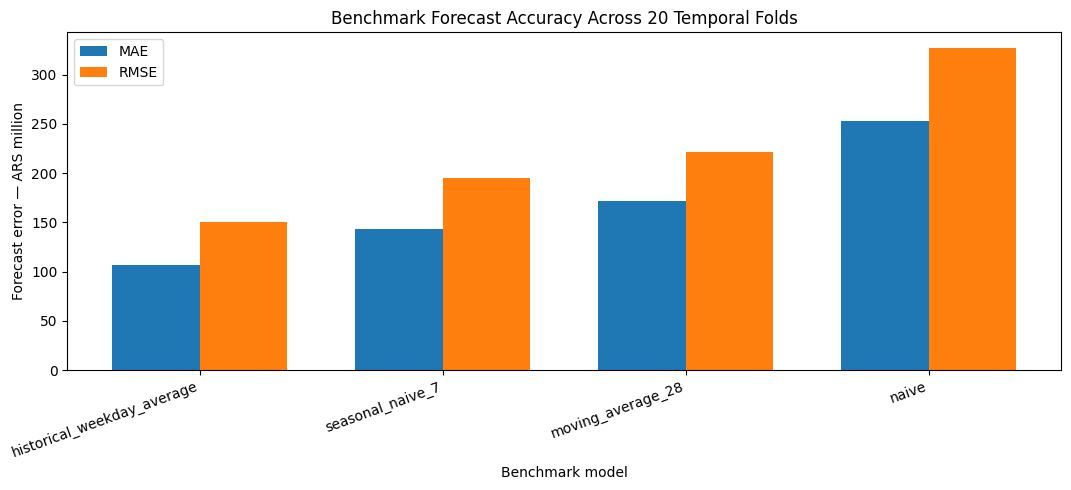

In [21]:
# ---------------------------------------------------------
# Visual comparison of benchmark accuracy
# ---------------------------------------------------------

metric_plot_data = (
    benchmark_metrics_summary
    .sort_values("mae")
    .reset_index(drop=True)
)

x_positions = np.arange(
    len(metric_plot_data)
)

bar_width = 0.36

fig, ax = plt.subplots(
    figsize=(11, 5)
)

ax.bar(
    x_positions - bar_width / 2,
    metric_plot_data["mae"],
    width=bar_width,
    label="MAE",
)

ax.bar(
    x_positions + bar_width / 2,
    metric_plot_data["rmse"],
    width=bar_width,
    label="RMSE",
)

ax.set_title(
    "Benchmark Forecast Accuracy Across 20 Temporal Folds"
)

ax.set_xlabel("Benchmark model")
ax.set_ylabel("Forecast error — ARS million")

ax.set_xticks(x_positions)
ax.set_xticklabels(
    metric_plot_data["model_name"],
    rotation=20,
    ha="right",
)

ax.legend()

fig.tight_layout()

save_figure(
    fig,
    "03_benchmark_mae_rmse_comparison.png",
)

plt.show()

### Benchmark Findings

The Historical Weekday Average is the strongest benchmark across the common
20-fold temporal backtest.

Its overall performance is:

- **MAE:** 106.58 ARS million.
- **RMSE:** 149.94 ARS million.
- **MAE improvement over Seasonal Naive:** 25.54%.
- **RMSE improvement over Seasonal Naive:** 23.13%.
- **MAE fold wins:** 18 out of 20.
- **RMSE fold wins:** 18 out of 20.

The model preserves the weekly behavioral structure while averaging the most
recent eight observations for each weekday. This reduces sensitivity to
isolated noise and extraordinary events.

Its main limitation is a negative bias of approximately **-3.80%**, which is
consistent with averaging recent historical weekdays in a series with a
strong upward trend.

Seasonal Naive remains an important reference because it has almost no
overall bias, but it is less accurate and less stable across forecast origins.

From this point onward, ETS models must demonstrate value against the
Historical Weekday Average rather than only against Seasonal Naive.

In [22]:
# ---------------------------------------------------------
# Benchmark metrics by forecast horizon
# ---------------------------------------------------------

benchmark_metrics_by_horizon = (
    benchmark_forecasts_scaled
    .groupby(
        [
            "model_name",
            "forecast_horizon",
        ],
        as_index=False,
    )
    .agg(
        observations=(
            "actual",
            "size",
        ),
        mean_actual=(
            "actual",
            "mean",
        ),
        mean_prediction=(
            "prediction",
            "mean",
        ),
        mae=(
            "absolute_error",
            "mean",
        ),
        mean_squared_error=(
            "squared_error",
            "mean",
        ),
        mase=(
            "absolute_scaled_error",
            "mean",
        ),
        mean_squared_scaled_error=(
            "squared_scaled_error",
            "mean",
        ),
        mean_error=(
            "error",
            "mean",
        ),
    )
)

benchmark_metrics_by_horizon["rmse"] = np.sqrt(
    benchmark_metrics_by_horizon[
        "mean_squared_error"
    ]
)

benchmark_metrics_by_horizon["rmsse"] = np.sqrt(
    benchmark_metrics_by_horizon[
        "mean_squared_scaled_error"
    ]
)

benchmark_metrics_by_horizon["bias_pct"] = (
    benchmark_metrics_by_horizon["mean_error"]
    / benchmark_metrics_by_horizon["mean_actual"]
    * 100
)

benchmark_metrics_by_horizon = (
    benchmark_metrics_by_horizon[
        [
            "model_name",
            "forecast_horizon",
            "observations",
            "mean_actual",
            "mean_prediction",
            "mae",
            "rmse",
            "mase",
            "rmsse",
            "mean_error",
            "bias_pct",
        ]
    ]
    .sort_values(
        [
            "model_name",
            "forecast_horizon",
        ]
    )
    .reset_index(drop=True)
)

metric_columns = [
    "mean_actual",
    "mean_prediction",
    "mae",
    "rmse",
    "mase",
    "rmsse",
    "mean_error",
    "bias_pct",
]

benchmark_metrics_by_horizon[
    metric_columns
] = (
    benchmark_metrics_by_horizon[
        metric_columns
    ]
    .round(3)
)

save_table(
    benchmark_metrics_by_horizon,
    "03_benchmark_metrics_by_horizon.csv",
)

benchmark_metrics_by_horizon.head(12)

Table saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\03_benchmark_metrics_by_horizon.csv


,model_name,forecast_horizon,observations,mean_actual,mean_prediction,mae,rmse,mase,rmsse,mean_error,bias_pct
0,historical_weekday_average,1,20,740.728,706.226,66.089,101.510,0.698,0.780,-34.502,-4.658
1,historical_weekday_average,2,20,580.138,553.742,42.436,53.066,0.455,0.418,-26.397,-4.550
2,historical_weekday_average,3,20,995.672,990.173,116.389,149.469,1.251,1.192,-5.499,-0.552
3,historical_weekday_average,4,20,950.133,945.508,116.082,145.310,1.232,1.111,-4.625,-0.487
4,historical_weekday_average,5,20,971.448,963.872,121.046,147.591,1.303,1.182,-7.577,-0.780
5,historical_weekday_average,6,20,947.252,927.257,110.877,137.222,1.163,1.040,-19.995,-2.111
6,historical_weekday_average,7,20,1087.910,1025.358,140.767,181.931,1.456,1.339,-62.552,-5.750
7,historical_weekday_average,8,20,726.126,706.226,62.178,80.435,0.664,0.620,-19.900,-2.741
8,historical_weekday_average,9,20,566.140,553.742,56.654,80.741,0.568,0.561,-12.399,-2.190
9,historical_weekday_average,10,20,1034.126,990.173,138.682,200.753,1.423,1.480,-43.953,-4.250


In [23]:
expected_horizon_rows = (
    len(benchmark_model_names)
    * FORECAST_HORIZON
)

horizon_group_checks = (
    benchmark_metrics_by_horizon
    .groupby("model_name")[
        "forecast_horizon"
    ]
    .agg(["min", "max", "nunique"])
)

assert len(
    benchmark_metrics_by_horizon
) == expected_horizon_rows, (
    "The horizon-metric table has an incorrect number of rows."
)

assert horizon_group_checks["min"].eq(1).all()
assert horizon_group_checks["max"].eq(28).all()
assert horizon_group_checks["nunique"].eq(28).all()

assert benchmark_metrics_by_horizon[
    [
        "mae",
        "rmse",
        "mase",
        "rmsse",
    ]
].gt(0).all().all(), (
    "Invalid horizon-level error metrics were detected."
)

print(
    "Benchmark horizon-metric validation "
    "passed successfully."
)

Benchmark horizon-metric validation passed successfully.


Figure saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\figures\03_benchmark_mae_by_horizon.png


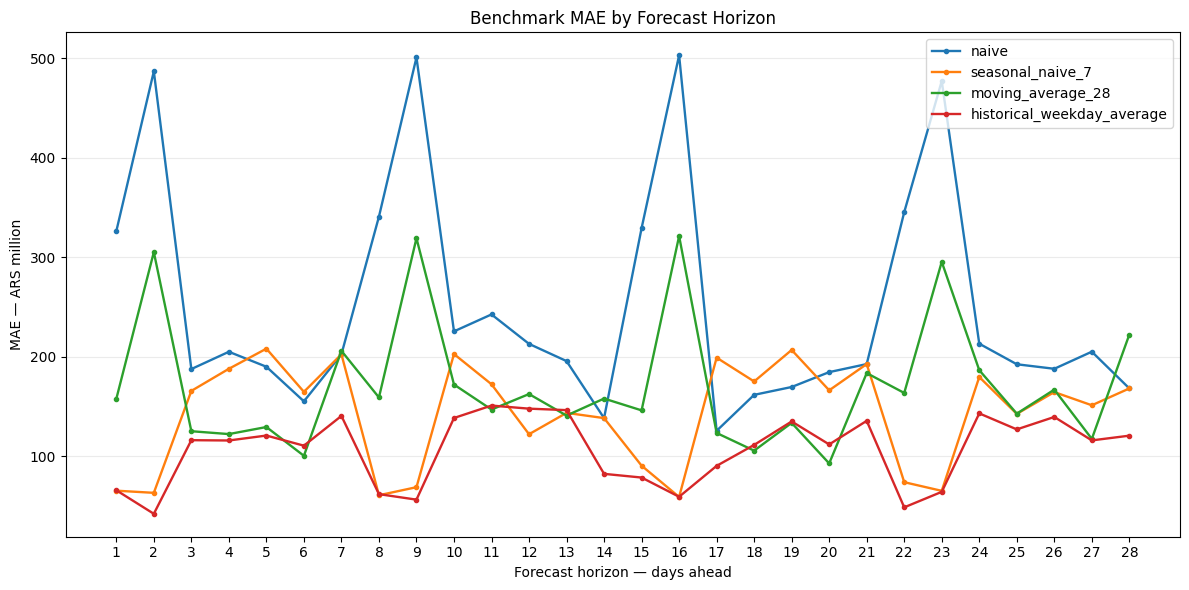

In [24]:
# ---------------------------------------------------------
# MAE evolution across the 28-day forecast horizon
# ---------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(12, 6)
)

for model_name in benchmark_model_names:
    model_horizon_data = (
        benchmark_metrics_by_horizon.loc[
            benchmark_metrics_by_horizon[
                "model_name"
            ].eq(model_name)
        ]
        .sort_values("forecast_horizon")
    )

    ax.plot(
        model_horizon_data[
            "forecast_horizon"
        ],
        model_horizon_data["mae"],
        marker="o",
        markersize=3,
        linewidth=1.7,
        label=model_name,
    )

ax.set_title(
    "Benchmark MAE by Forecast Horizon"
)

ax.set_xlabel("Forecast horizon — days ahead")
ax.set_ylabel("MAE — ARS million")

ax.set_xticks(
    range(
        1,
        FORECAST_HORIZON + 1,
    )
)

ax.grid(
    axis="y",
    alpha=0.25,
)

ax.legend()

fig.tight_layout()

save_figure(
    fig,
    "03_benchmark_mae_by_horizon.png",
)

plt.show()

In [25]:
# ---------------------------------------------------------
# Identify the best benchmark at each forecast horizon
# ---------------------------------------------------------

best_benchmark_by_horizon = (
    benchmark_metrics_by_horizon.loc[
        benchmark_metrics_by_horizon
        .groupby("forecast_horizon")["mae"]
        .idxmin(),
        [
            "forecast_horizon",
            "model_name",
            "mae",
            "rmse",
            "mean_error",
            "bias_pct",
        ],
    ]
    .rename(
        columns={
            "model_name": "best_model_by_mae",
        }
    )
    .sort_values("forecast_horizon")
    .reset_index(drop=True)
)

save_table(
    best_benchmark_by_horizon,
    "03_best_benchmark_by_horizon.csv",
)

horizon_winner_summary = (
    best_benchmark_by_horizon[
        "best_model_by_mae"
    ]
    .value_counts()
    .rename_axis("model_name")
    .reset_index(name="number_of_horizons_won")
)

save_table(
    horizon_winner_summary,
    "03_benchmark_horizon_winner_summary.csv",
)

display(horizon_winner_summary)
display(best_benchmark_by_horizon)

Table saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\03_best_benchmark_by_horizon.csv
Table saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\03_benchmark_horizon_winner_summary.csv


,model_name,number_of_horizons_won
0,historical_weekday_average,18
1,moving_average_28,6
2,seasonal_naive_7,4


,forecast_horizon,best_model_by_mae,mae,rmse,mean_error,bias_pct
0,1,seasonal_naive_7,65.659,89.669,-35.639,-4.811
1,2,historical_weekday_average,42.436,53.066,-26.397,-4.550
2,3,historical_weekday_average,116.389,149.469,-5.499,-0.552
3,4,historical_weekday_average,116.082,145.310,-4.625,-0.487
4,5,historical_weekday_average,121.046,147.591,-7.577,-0.780
5,6,moving_average_28,100.703,125.075,-61.828,-6.527
6,7,historical_weekday_average,140.767,181.931,-62.552,-5.750
7,8,seasonal_naive_7,61.069,81.060,-21.037,-2.897
8,9,historical_weekday_average,56.654,80.741,-12.399,-2.190
9,10,historical_weekday_average,138.682,200.753,-43.953,-4.250


### Forecast-Horizon Findings

The Historical Weekday Average is the most accurate benchmark across most of
the 28-day forecasting horizon.

- It achieves the lowest MAE at **18 of the 28 horizons**.
- The 28-day Moving Average wins at 6 horizons.
- Seasonal Naive wins at 4 horizons.
- The simple Naive model does not win at any horizon.

The periodic error pattern observed for Naive and Moving Average is explained
by their constant forecasts. Their errors increase on weekdays whose expected
cash-outflow levels differ substantially from the constant prediction.

Historical Weekday Average retains the weekly structure and is therefore the
empirical benchmark that ETS models must outperform.

## ETS Candidate Models

Exponential Smoothing models are evaluated as the first statistical
alternative to the benchmark forecasts.

A limited set of configurations is considered:

1. Additive trend and additive weekly seasonality on the original scale.
2. Damped additive trend and additive weekly seasonality.
3. Additive trend and multiplicative weekly seasonality.
4. Damped additive trend and multiplicative weekly seasonality.
5. Additive trend and additive weekly seasonality on the logarithmic scale.
6. Damped additive trend and additive weekly seasonality on the logarithmic
   scale.

The logarithmic specifications represent multiplicative behavior on the
original scale. Their forecasts are converted back to ARS millions using a
lognormal bias adjustment:

$$
\hat{y}_{t+h}
=
\exp
\left(
\hat{z}_{t+h}
+
\frac{\hat{\sigma}^{2}}{2}
\right)
$$

where $\hat{z}_{t+h}$ is the forecast on the logarithmic scale and
$\hat{\sigma}^{2}$ is the training residual variance.

A smoke test is first performed on the final temporal fold. Model selection
will not be based on this single fold; all successful candidates will later
be evaluated over the common 20-fold backtest.

In [26]:
# ---------------------------------------------------------
# ETS candidate definitions
# ---------------------------------------------------------

ets_candidate_definitions = pd.DataFrame(
    [
        {
            "model_name": "ets_original_additive",
            "scale": "original",
            "trend": "add",
            "damped_trend": False,
            "seasonal": "add",
            "seasonal_periods": SEASONAL_PERIOD,
            "bias_adjustment": False,
        },
        {
            "model_name": "ets_original_damped_additive",
            "scale": "original",
            "trend": "add",
            "damped_trend": True,
            "seasonal": "add",
            "seasonal_periods": SEASONAL_PERIOD,
            "bias_adjustment": False,
        },
        {
            "model_name": "ets_original_multiplicative",
            "scale": "original",
            "trend": "add",
            "damped_trend": False,
            "seasonal": "mul",
            "seasonal_periods": SEASONAL_PERIOD,
            "bias_adjustment": False,
        },
        {
            "model_name": "ets_original_damped_multiplicative",
            "scale": "original",
            "trend": "add",
            "damped_trend": True,
            "seasonal": "mul",
            "seasonal_periods": SEASONAL_PERIOD,
            "bias_adjustment": False,
        },
        {
            "model_name": "ets_log_additive",
            "scale": "log",
            "trend": "add",
            "damped_trend": False,
            "seasonal": "add",
            "seasonal_periods": SEASONAL_PERIOD,
            "bias_adjustment": True,
        },
        {
            "model_name": "ets_log_damped_additive",
            "scale": "log",
            "trend": "add",
            "damped_trend": True,
            "seasonal": "add",
            "seasonal_periods": SEASONAL_PERIOD,
            "bias_adjustment": True,
        },
    ]
)

save_table(
    ets_candidate_definitions,
    "03_ets_candidate_definitions.csv",
)

ets_candidate_definitions

Table saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\03_ets_candidate_definitions.csv


,model_name,scale,trend,damped_trend,seasonal,seasonal_periods,bias_adjustment
0,ets_original_additive,original,add,False,add,7,False
1,ets_original_damped_additive,original,add,True,add,7,False
2,ets_original_multiplicative,original,add,False,mul,7,False
3,ets_original_damped_multiplicative,original,add,True,mul,7,False
4,ets_log_additive,log,add,False,add,7,True
5,ets_log_damped_additive,log,add,True,add,7,True


In [27]:
import warnings


def fit_and_forecast_ets(
    training_values,
    forecast_horizon,
    configuration,
):
    """
    Fit one ETS candidate and generate point forecasts.

    Parameters
    ----------
    training_values : array-like
        Positive target observations available at the forecast origin.
    forecast_horizon : int
        Number of future observations to predict.
    configuration : dict
        ETS configuration containing scale, trend, damping, and seasonality.

    Returns
    -------
    predictions : numpy.ndarray
        Forecasts expressed on the original ARS-million scale.
    diagnostics : dict
        In-sample fit statistics and transformation information.
    """
    values = np.asarray(
        training_values,
        dtype=float,
    )

    if len(values) < 2 * configuration["seasonal_periods"]:
        raise ValueError(
            "The training series is too short for seasonal ETS."
        )

    if not np.isfinite(values).all():
        raise ValueError(
            "The training series contains invalid numeric values."
        )

    if np.any(values <= 0):
        raise ValueError(
            "ETS candidates require strictly positive target values."
        )

    if configuration["scale"] == "log":
        model_values = np.log(values)
    elif configuration["scale"] == "original":
        model_values = values.copy()
    else:
        raise ValueError(
            f"Unsupported scale: {configuration['scale']}"
        )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        model = ExponentialSmoothing(
            model_values,
            trend=configuration["trend"],
            damped_trend=configuration["damped_trend"],
            seasonal=configuration["seasonal"],
            seasonal_periods=configuration["seasonal_periods"],
            initialization_method="estimated",
        )

        fitted_model = model.fit(
            optimized=True,
            use_brute=True,
        )

    transformed_forecast = np.asarray(
        fitted_model.forecast(
            forecast_horizon
        ),
        dtype=float,
    )

    residuals = np.asarray(
        fitted_model.resid,
        dtype=float,
    )

    residual_variance = float(
        np.var(
            residuals,
            ddof=1,
        )
    )

    bias_adjustment_factor = 1.0

    if configuration["scale"] == "log":
        if configuration["bias_adjustment"]:
            bias_adjustment_factor = float(
                np.exp(
                    0.5 * residual_variance
                )
            )

        predictions = (
            np.exp(transformed_forecast)
            * bias_adjustment_factor
        )
    else:
        predictions = transformed_forecast

    if len(predictions) != forecast_horizon:
        raise ValueError(
            "ETS returned an incorrect forecast length."
        )

    if not np.isfinite(predictions).all():
        raise ValueError(
            "ETS generated non-finite predictions."
        )

    if np.any(predictions <= 0):
        raise ValueError(
            "ETS generated non-positive predictions."
        )

    diagnostics = {
        "aic": float(fitted_model.aic),
        "bic": float(fitted_model.bic),
        "sse": float(fitted_model.sse),
        "residual_variance": residual_variance,
        "bias_adjustment_factor": (
            bias_adjustment_factor
        ),
    }

    return predictions, diagnostics

In [28]:
# ---------------------------------------------------------
# ETS smoke test on the final temporal fold
# ---------------------------------------------------------

smoke_test_fold = (
    backtest_folds.iloc[-1]
)

smoke_training_data = (
    df.iloc[
        int(smoke_test_fold["train_start_position"]):
        int(smoke_test_fold["train_end_position"]) + 1
    ]
    .copy()
)

smoke_test_data = (
    df.iloc[
        int(smoke_test_fold["test_start_position"]):
        int(smoke_test_fold["test_end_position"]) + 1
    ]
    .copy()
)

smoke_training_values = (
    smoke_training_data[TARGET]
    .to_numpy(dtype=float)
)

smoke_actual_values = (
    smoke_test_data[TARGET]
    .to_numpy(dtype=float)
)

smoke_forecast_frames = []
smoke_metric_rows = []
smoke_diagnostic_rows = []


# Strongest empirical benchmark in the same fold
benchmark_reference_metrics = (
    benchmark_metrics_by_fold.loc[
        benchmark_metrics_by_fold[
            "fold_id"
        ].eq(smoke_test_fold["fold_id"])
        & benchmark_metrics_by_fold[
            "model_name"
        ].eq("historical_weekday_average")
    ]
)

if len(benchmark_reference_metrics) != 1:
    raise ValueError(
        "The reference benchmark metrics are missing."
    )

reference_mae = float(
    benchmark_reference_metrics["mae"].iloc[0]
)

reference_rmse = float(
    benchmark_reference_metrics["rmse"].iloc[0]
)


for configuration in (
    ets_candidate_definitions.to_dict(
        orient="records"
    )
):
    model_name = configuration["model_name"]

    try:
        predictions, diagnostics = (
            fit_and_forecast_ets(
                training_values=smoke_training_values,
                forecast_horizon=FORECAST_HORIZON,
                configuration=configuration,
            )
        )

        errors = (
            predictions
            - smoke_actual_values
        )

        absolute_errors = np.abs(errors)
        squared_errors = errors**2

        mae = float(
            absolute_errors.mean()
        )

        rmse = float(
            np.sqrt(
                squared_errors.mean()
            )
        )

        mean_error = float(
            errors.mean()
        )

        bias_pct = float(
            mean_error
            / smoke_actual_values.mean()
            * 100
        )

        smoke_forecast_frames.append(
            pd.DataFrame(
                {
                    "fold_id": (
                        smoke_test_fold["fold_id"]
                    ),
                    "model_name": model_name,
                    "forecast_origin": (
                        smoke_test_fold[
                            "forecast_origin"
                        ]
                    ),
                    "target_date": (
                        smoke_test_data[
                            DATE_COLUMN
                        ].to_numpy()
                    ),
                    "forecast_horizon": np.arange(
                        1,
                        FORECAST_HORIZON + 1,
                    ),
                    "actual": smoke_actual_values,
                    "prediction": predictions,
                    "error": errors,
                    "absolute_error": (
                        absolute_errors
                    ),
                    "squared_error": (
                        squared_errors
                    ),
                }
            )
        )

        smoke_metric_rows.append(
            {
                "model_name": model_name,
                "status": "success",
                "observations": (
                    FORECAST_HORIZON
                ),
                "mae": mae,
                "rmse": rmse,
                "mean_error": mean_error,
                "bias_pct": bias_pct,
                "mae_improvement_vs_historical_weekday_pct": (
                    (
                        reference_mae - mae
                    )
                    / reference_mae
                    * 100
                ),
                "rmse_improvement_vs_historical_weekday_pct": (
                    (
                        reference_rmse - rmse
                    )
                    / reference_rmse
                    * 100
                ),
            }
        )

        smoke_diagnostic_rows.append(
            {
                "model_name": model_name,
                "status": "success",
                "scale": configuration["scale"],
                "trend": configuration["trend"],
                "damped_trend": (
                    configuration[
                        "damped_trend"
                    ]
                ),
                "seasonal": (
                    configuration["seasonal"]
                ),
                "aic": diagnostics["aic"],
                "bic": diagnostics["bic"],
                "sse": diagnostics["sse"],
                "residual_variance": (
                    diagnostics[
                        "residual_variance"
                    ]
                ),
                "bias_adjustment_factor": (
                    diagnostics[
                        "bias_adjustment_factor"
                    ]
                ),
                "error_message": "",
            }
        )

    except Exception as error:
        smoke_metric_rows.append(
            {
                "model_name": model_name,
                "status": "failed",
                "observations": 0,
                "mae": np.nan,
                "rmse": np.nan,
                "mean_error": np.nan,
                "bias_pct": np.nan,
                "mae_improvement_vs_historical_weekday_pct": np.nan,
                "rmse_improvement_vs_historical_weekday_pct": np.nan,
            }
        )

        smoke_diagnostic_rows.append(
            {
                "model_name": model_name,
                "status": "failed",
                "scale": configuration["scale"],
                "trend": configuration["trend"],
                "damped_trend": (
                    configuration[
                        "damped_trend"
                    ]
                ),
                "seasonal": (
                    configuration["seasonal"]
                ),
                "aic": np.nan,
                "bic": np.nan,
                "sse": np.nan,
                "residual_variance": np.nan,
                "bias_adjustment_factor": np.nan,
                "error_message": str(error),
            }
        )


ets_smoke_test_forecasts = pd.concat(
    smoke_forecast_frames,
    ignore_index=True,
)

ets_smoke_test_metrics = pd.DataFrame(
    smoke_metric_rows
)

ets_smoke_test_fit_diagnostics = pd.DataFrame(
    smoke_diagnostic_rows
)


ets_smoke_test_metrics = (
    ets_smoke_test_metrics
    .sort_values(
        ["status", "mae"],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

metric_columns = [
    "mae",
    "rmse",
    "mean_error",
    "bias_pct",
    "mae_improvement_vs_historical_weekday_pct",
    "rmse_improvement_vs_historical_weekday_pct",
]

ets_smoke_test_metrics[
    metric_columns
] = (
    ets_smoke_test_metrics[
        metric_columns
    ]
    .round(3)
)

diagnostic_numeric_columns = [
    "aic",
    "bic",
    "sse",
    "residual_variance",
    "bias_adjustment_factor",
]

ets_smoke_test_fit_diagnostics[
    diagnostic_numeric_columns
] = (
    ets_smoke_test_fit_diagnostics[
        diagnostic_numeric_columns
    ]
    .round(5)
)


save_table(
    ets_smoke_test_forecasts,
    "03_ets_smoke_test_forecasts.csv",
)

save_table(
    ets_smoke_test_metrics,
    "03_ets_smoke_test_metrics.csv",
)

save_table(
    ets_smoke_test_fit_diagnostics,
    "03_ets_smoke_test_fit_diagnostics.csv",
)

display(ets_smoke_test_metrics)
display(ets_smoke_test_fit_diagnostics)

Table saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\03_ets_smoke_test_forecasts.csv
Table saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\03_ets_smoke_test_metrics.csv
Table saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\03_ets_smoke_test_fit_diagnostics.csv


,model_name,status,observations,mae,rmse,mean_error,bias_pct,mae_improvement_vs_historical_weekday_pct,rmse_improvement_vs_historical_weekday_pct
0,ets_original_multiplicative,success,28,157.604,189.924,77.938,6.726,-12.650,-7.953
1,ets_log_additive,success,28,159.077,191.436,84.365,7.280,-13.702,-8.813
2,ets_log_damped_additive,success,28,161.157,194.092,90.312,7.794,-15.190,-10.323
3,ets_original_damped_multiplicative,success,28,164.642,198.859,96.707,8.345,-17.680,-13.032
4,ets_original_additive,success,28,171.317,197.381,91.015,7.854,-22.451,-12.192
5,ets_original_damped_additive,success,28,172.339,198.148,93.382,8.058,-23.182,-12.628


,model_name,status,scale,trend,damped_trend,seasonal,aic,bic,sse,residual_variance,bias_adjustment_factor,error_message
0,ets_original_additive,success,original,add,False,add,11982.34440,12039.04517,1.463073e+07,11426.95151,1.00000,
1,ets_original_damped_additive,success,original,add,True,add,11988.20223,12050.05761,1.467489e+07,11433.23478,1.00000,
2,ets_original_multiplicative,success,original,add,False,mul,11925.96441,11982.66518,1.400028e+07,10934.02269,1.00000,
3,ets_original_damped_multiplicative,success,original,add,True,mul,11933.43014,11995.28552,1.406019e+07,10958.71095,1.00000,
4,ets_log_additive,success,log,add,False,add,-5048.82186,-4992.12109,2.436227e+01,0.01905,1.00957,
5,ets_log_damped_additive,success,log,add,True,add,-5035.57966,-4973.72428,2.457719e+01,0.01915,1.00962,


In [29]:
# ---------------------------------------------------------
# Validate the ETS smoke-test outputs
# ---------------------------------------------------------

successful_ets_models = (
    ets_smoke_test_metrics.loc[
        ets_smoke_test_metrics[
            "status"
        ].eq("success"),
        "model_name",
    ]
    .tolist()
)

expected_successful_forecast_rows = (
    len(successful_ets_models)
    * FORECAST_HORIZON
)

ets_smoke_test_checks = pd.Series(
    {
        "configured_candidates": len(
            ets_candidate_definitions
        ),

        "successful_candidates": len(
            successful_ets_models
        ),

        "failed_candidates": int(
            ets_smoke_test_metrics[
                "status"
            ]
            .eq("failed")
            .sum()
        ),

        "expected_successful_forecast_rows": (
            expected_successful_forecast_rows
        ),

        "generated_forecast_rows": len(
            ets_smoke_test_forecasts
        ),

        "missing_forecast_values": int(
            ets_smoke_test_forecasts
            .isna()
            .sum()
            .sum()
        ),

        "non_positive_predictions": int(
            ets_smoke_test_forecasts[
                "prediction"
            ]
            .le(0)
            .sum()
        ),

        "duplicated_forecast_rows": int(
            ets_smoke_test_forecasts
            .duplicated(
                subset=[
                    "fold_id",
                    "model_name",
                    "target_date",
                ]
            )
            .sum()
        ),
    },
    name="value",
).rename_axis("check").reset_index()

save_table(
    ets_smoke_test_checks,
    "03_ets_smoke_test_checks.csv",
)

ets_smoke_test_checks

Table saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\03_ets_smoke_test_checks.csv


,check,value
0,configured_candidates,6
1,successful_candidates,6
2,failed_candidates,0
3,expected_successful_forecast_rows,168
4,generated_forecast_rows,168
5,missing_forecast_values,0
6,non_positive_predictions,0
7,duplicated_forecast_rows,0


Figure saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\figures\03_ets_smoke_test_last_fold.png


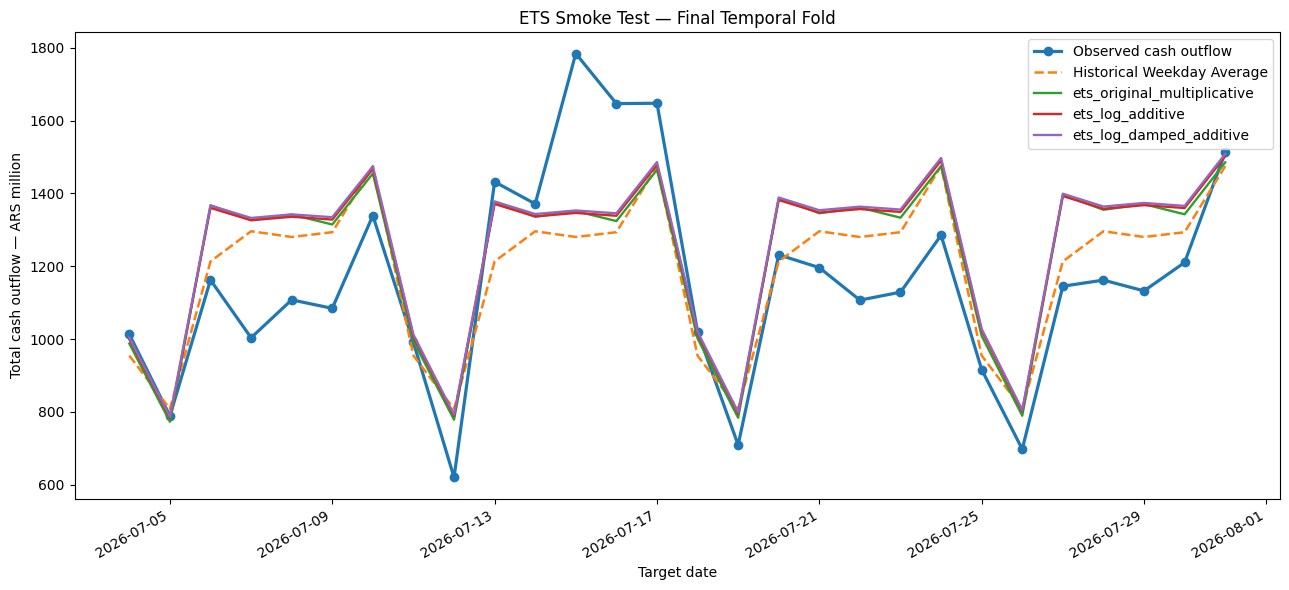

In [30]:
# ---------------------------------------------------------
# Visual comparison of the best smoke-test ETS candidates
# ---------------------------------------------------------

top_smoke_test_models = (
    ets_smoke_test_metrics.loc[
        ets_smoke_test_metrics[
            "status"
        ].eq("success")
    ]
    .nsmallest(
        3,
        "mae",
    )["model_name"]
    .tolist()
)

historical_weekday_last_fold = (
    benchmark_forecasts.loc[
        benchmark_forecasts[
            "fold_id"
        ].eq(
            smoke_test_fold["fold_id"]
        )
        & benchmark_forecasts[
            "model_name"
        ].eq(
            "historical_weekday_average"
        )
    ]
    .sort_values("target_date")
)

fig, ax = plt.subplots(
    figsize=(13, 6)
)

ax.plot(
    smoke_test_data[DATE_COLUMN],
    smoke_actual_values,
    marker="o",
    linewidth=2.3,
    label="Observed cash outflow",
)

ax.plot(
    historical_weekday_last_fold[
        "target_date"
    ],
    historical_weekday_last_fold[
        "prediction"
    ],
    linewidth=1.8,
    linestyle="--",
    label="Historical Weekday Average",
)

for model_name in top_smoke_test_models:
    model_forecasts = (
        ets_smoke_test_forecasts.loc[
            ets_smoke_test_forecasts[
                "model_name"
            ].eq(model_name)
        ]
        .sort_values("target_date")
    )

    ax.plot(
        model_forecasts["target_date"],
        model_forecasts["prediction"],
        linewidth=1.7,
        label=model_name,
    )

ax.set_title(
    "ETS Smoke Test — Final Temporal Fold"
)

ax.set_xlabel("Target date")
ax.set_ylabel(
    "Total cash outflow — ARS million"
)

ax.legend()
fig.autofmt_xdate()
fig.tight_layout()

save_figure(
    fig,
    "03_ets_smoke_test_last_fold.png",
)

plt.show()

### ETS Smoke-Test Findings

All six ETS candidates completed the final-fold smoke test successfully.

No missing, duplicated, infinite, or non-positive forecasts were generated.

The best ETS candidate in this single fold was
`ets_original_multiplicative`, with:

- MAE of 157.60 ARS million.
- RMSE of 189.92 ARS million.
- Positive bias of approximately 6.73%.

However, none of the ETS candidates outperformed the Historical Weekday
Average in this fold. Their MAE deterioration relative to the benchmark
ranged from approximately 12.7% to 23.2%.

All ETS candidates showed positive bias between approximately 6.7% and 8.3%,
indicating systematic over-forecasting during the final test window.

This smoke test verifies numerical validity and implementation correctness.
It is not used for model selection. All six technically valid candidates will
be evaluated across the common 20-fold temporal backtest.

AIC and BIC values will only be compared among models fitted on the same
target scale. Values from original-scale and logarithmic-scale models are not
directly comparable.

In [31]:
# ---------------------------------------------------------
# Full 20-fold ETS temporal backtest
# ---------------------------------------------------------

ets_forecast_frames = []
ets_fit_rows = []
ets_failure_rows = []

ets_configurations = (
    ets_candidate_definitions
    .to_dict(orient="records")
)

total_model_fold_combinations = (
    len(backtest_folds)
    * len(ets_configurations)
)

completed_combinations = 0


for fold in backtest_folds.itertuples(index=False):
    training_data = (
        df.iloc[
            fold.train_start_position:
            fold.train_end_position + 1
        ]
        .copy()
    )

    test_data = (
        df.iloc[
            fold.test_start_position:
            fold.test_end_position + 1
        ]
        .copy()
    )

    training_values = (
        training_data[TARGET]
        .to_numpy(dtype=float)
    )

    actual_values = (
        test_data[TARGET]
        .to_numpy(dtype=float)
    )

    for configuration in ets_configurations:
        model_name = configuration["model_name"]

        completed_combinations += 1

        print(
            f"Fitting {completed_combinations}/"
            f"{total_model_fold_combinations}: "
            f"{fold.fold_id} — {model_name}",
            end="\r",
        )

        try:
            predictions, diagnostics = (
                fit_and_forecast_ets(
                    training_values=training_values,
                    forecast_horizon=FORECAST_HORIZON,
                    configuration=configuration,
                )
            )

            errors = (
                predictions
                - actual_values
            )

            forecast_frame = pd.DataFrame(
                {
                    "fold_id": fold.fold_id,
                    "model_name": model_name,
                    "forecast_origin": (
                        fold.forecast_origin
                    ),
                    "target_date": (
                        test_data[DATE_COLUMN]
                        .to_numpy()
                    ),
                    "forecast_horizon": np.arange(
                        1,
                        FORECAST_HORIZON + 1,
                    ),
                    "actual": actual_values,
                    "prediction": predictions,
                    "error": errors,
                    "absolute_error": np.abs(
                        errors
                    ),
                    "squared_error": (
                        errors**2
                    ),
                }
            )

            ets_forecast_frames.append(
                forecast_frame
            )

            ets_fit_rows.append(
                {
                    "fold_id": fold.fold_id,
                    "model_name": model_name,
                    "forecast_origin": (
                        fold.forecast_origin
                    ),
                    "training_observations": (
                        len(training_values)
                    ),
                    "status": "success",
                    "scale": configuration["scale"],
                    "trend": configuration["trend"],
                    "damped_trend": (
                        configuration[
                            "damped_trend"
                        ]
                    ),
                    "seasonal": (
                        configuration["seasonal"]
                    ),
                    "seasonal_periods": (
                        configuration[
                            "seasonal_periods"
                        ]
                    ),
                    "aic": diagnostics["aic"],
                    "bic": diagnostics["bic"],
                    "sse": diagnostics["sse"],
                    "residual_variance": (
                        diagnostics[
                            "residual_variance"
                        ]
                    ),
                    "bias_adjustment_factor": (
                        diagnostics[
                            "bias_adjustment_factor"
                        ]
                    ),
                }
            )

        except Exception as error:
            ets_failure_rows.append(
                {
                    "fold_id": fold.fold_id,
                    "model_name": model_name,
                    "forecast_origin": (
                        fold.forecast_origin
                    ),
                    "scale": configuration["scale"],
                    "trend": configuration["trend"],
                    "damped_trend": (
                        configuration[
                            "damped_trend"
                        ]
                    ),
                    "seasonal": (
                        configuration["seasonal"]
                    ),
                    "error_type": (
                        type(error).__name__
                    ),
                    "error_message": str(error),
                }
            )


print(
    "\nETS backtest fitting completed."
)


# ---------------------------------------------------------
# Combine successful forecast outputs
# ---------------------------------------------------------

if not ets_forecast_frames:
    raise RuntimeError(
        "No ETS candidate completed the backtest successfully."
    )

ets_backtest_forecasts = pd.concat(
    ets_forecast_frames,
    ignore_index=True,
)

ets_backtest_forecasts = (
    ets_backtest_forecasts
    .sort_values(
        [
            "fold_id",
            "model_name",
            "forecast_horizon",
        ]
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------
# Add training-only MASE and RMSSE scales
# ---------------------------------------------------------

ets_backtest_forecasts = (
    ets_backtest_forecasts
    .merge(
        benchmark_scaling_by_fold[
            [
                "fold_id",
                "mase_scale",
                "rmsse_scale",
            ]
        ],
        on="fold_id",
        how="left",
        validate="many_to_one",
    )
)

ets_backtest_forecasts[
    "absolute_scaled_error"
] = (
    ets_backtest_forecasts[
        "absolute_error"
    ]
    / ets_backtest_forecasts[
        "mase_scale"
    ]
)

ets_backtest_forecasts[
    "squared_scaled_error"
] = (
    ets_backtest_forecasts[
        "squared_error"
    ]
    / ets_backtest_forecasts[
        "rmsse_scale"
    ]
)


# ---------------------------------------------------------
# Fit diagnostics and failure tables
# ---------------------------------------------------------

ets_backtest_fit_diagnostics = (
    pd.DataFrame(ets_fit_rows)
    .sort_values(
        [
            "fold_id",
            "model_name",
        ]
    )
    .reset_index(drop=True)
)

failure_columns = [
    "fold_id",
    "model_name",
    "forecast_origin",
    "scale",
    "trend",
    "damped_trend",
    "seasonal",
    "error_type",
    "error_message",
]

ets_backtest_failures = pd.DataFrame(
    ets_failure_rows,
    columns=failure_columns,
)


# ---------------------------------------------------------
# Round diagnostic values only
# ---------------------------------------------------------

diagnostic_numeric_columns = [
    "aic",
    "bic",
    "sse",
    "residual_variance",
    "bias_adjustment_factor",
]

ets_backtest_fit_diagnostics[
    diagnostic_numeric_columns
] = (
    ets_backtest_fit_diagnostics[
        diagnostic_numeric_columns
    ]
    .round(5)
)


# ---------------------------------------------------------
# Save outputs
# ---------------------------------------------------------

save_table(
    ets_backtest_forecasts,
    "03_ets_backtest_forecasts.csv",
)

save_table(
    ets_backtest_fit_diagnostics,
    "03_ets_backtest_fit_diagnostics.csv",
)

save_table(
    ets_backtest_failures,
    "03_ets_backtest_failures.csv",
)

print(
    "ETS forecast table shape: "
    f"{ets_backtest_forecasts.shape}"
)

print(
    "Successful model-fold fits: "
    f"{len(ets_backtest_fit_diagnostics)}"
)

print(
    "Failed model-fold fits: "
    f"{len(ets_backtest_failures)}"
)

ets_backtest_forecasts.head(12)

Fitting 120/120: fold_20 — ets_log_damped_additivetiplicative
ETS backtest fitting completed.
Table saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\03_ets_backtest_forecasts.csv
Table saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\03_ets_backtest_fit_diagnostics.csv
Table saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\03_ets_backtest_failures.csv
ETS forecast table shape: (3360, 14)
Successful model-fold fits: 120
Failed model-fold fits: 0


,fold_id,model_name,forecast_origin,target_date,forecast_horizon,actual,prediction,error,absolute_error,squared_error,mase_scale,rmsse_scale,absolute_scaled_error,squared_scaled_error
0,fold_01,ets_log_additive,2025-01-17,2025-01-18,1,692.977,601.060744,-91.916256,91.916256,8448.598051,80.748053,12306.372514,1.138309,0.686522
1,fold_01,ets_log_additive,2025-01-17,2025-01-19,2,468.426,469.847951,1.421951,1.421951,2.021943,80.748053,12306.372514,0.017610,0.000164
2,fold_01,ets_log_additive,2025-01-17,2025-01-20,3,774.585,804.306891,29.721891,29.721891,883.390777,80.748053,12306.372514,0.368082,0.071783
3,fold_01,ets_log_additive,2025-01-17,2025-01-21,4,758.083,795.159983,37.076983,37.076983,1374.702633,80.748053,12306.372514,0.459169,0.111707
4,fold_01,ets_log_additive,2025-01-17,2025-01-22,5,721.854,789.291764,67.437764,67.437764,4547.852039,80.748053,12306.372514,0.835163,0.369553
5,fold_01,ets_log_additive,2025-01-17,2025-01-23,6,569.272,808.181445,238.909445,238.909445,57077.722998,80.748053,12306.372514,2.958702,4.638062
6,fold_01,ets_log_additive,2025-01-17,2025-01-24,7,797.000,890.376232,93.376232,93.376232,8719.120774,80.748053,12306.372514,1.156390,0.708505
7,fold_01,ets_log_additive,2025-01-17,2025-01-25,8,677.168,606.318577,-70.849423,70.849423,5019.640740,80.748053,12306.372514,0.877413,0.407890
8,fold_01,ets_log_additive,2025-01-17,2025-01-26,9,483.938,473.957988,-9.980012,9.980012,99.600649,80.748053,12306.372514,0.123594,0.008093
9,fold_01,ets_log_additive,2025-01-17,2025-01-27,10,788.197,811.342637,23.145637,23.145637,535.720513,80.748053,12306.372514,0.286640,0.043532


In [32]:
# ---------------------------------------------------------
# Validate full ETS backtest outputs
# ---------------------------------------------------------

configured_model_fold_combinations = (
    len(backtest_folds)
    * len(ets_candidate_definitions)
)

successful_model_fold_combinations = (
    len(ets_backtest_fit_diagnostics)
)

failed_model_fold_combinations = (
    len(ets_backtest_failures)
)

expected_successful_forecast_rows = (
    successful_model_fold_combinations
    * FORECAST_HORIZON
)

ets_group_sizes = (
    ets_backtest_forecasts
    .groupby(
        [
            "fold_id",
            "model_name",
        ]
    )
    .size()
)

ets_horizon_coverage = (
    ets_backtest_forecasts
    .groupby(
        [
            "fold_id",
            "model_name",
        ]
    )["forecast_horizon"]
    .agg(
        ["min", "max", "nunique"]
    )
)

ets_backtest_checks = pd.Series(
    {
        "configured_candidates": len(
            ets_candidate_definitions
        ),

        "number_of_folds": len(
            backtest_folds
        ),

        "configured_model_fold_combinations": (
            configured_model_fold_combinations
        ),

        "successful_model_fold_combinations": (
            successful_model_fold_combinations
        ),

        "failed_model_fold_combinations": (
            failed_model_fold_combinations
        ),

        "expected_successful_forecast_rows": (
            expected_successful_forecast_rows
        ),

        "generated_forecast_rows": len(
            ets_backtest_forecasts
        ),

        "duplicated_forecast_rows": int(
            ets_backtest_forecasts
            .duplicated(
                subset=[
                    "fold_id",
                    "model_name",
                    "target_date",
                ]
            )
            .sum()
        ),

        "missing_forecast_values": int(
            ets_backtest_forecasts
            .isna()
            .sum()
            .sum()
        ),

        "infinite_forecast_values": int(
            (
                ~np.isfinite(
                    ets_backtest_forecasts[
                        [
                            "actual",
                            "prediction",
                            "error",
                            "absolute_error",
                            "squared_error",
                            "absolute_scaled_error",
                            "squared_scaled_error",
                        ]
                    ]
                    .to_numpy(dtype=float)
                )
            )
            .sum()
        ),

        "non_positive_predictions": int(
            ets_backtest_forecasts[
                "prediction"
            ]
            .le(0)
            .sum()
        ),

        "incorrect_group_sizes": int(
            ets_group_sizes
            .ne(FORECAST_HORIZON)
            .sum()
        ),

        "incorrect_minimum_horizon": int(
            ets_horizon_coverage["min"]
            .ne(1)
            .sum()
        ),

        "incorrect_maximum_horizon": int(
            ets_horizon_coverage["max"]
            .ne(FORECAST_HORIZON)
            .sum()
        ),

        "incorrect_unique_horizons": int(
            ets_horizon_coverage[
                "nunique"
            ]
            .ne(FORECAST_HORIZON)
            .sum()
        ),
    },
    name="value",
).rename_axis("check").reset_index()

save_table(
    ets_backtest_checks,
    "03_ets_backtest_checks.csv",
)

ets_backtest_checks

Table saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\03_ets_backtest_checks.csv


,check,value
0,configured_candidates,6
1,number_of_folds,20
2,configured_model_fold_combinations,120
3,successful_model_fold_combinations,120
4,failed_model_fold_combinations,0
5,expected_successful_forecast_rows,3360
6,generated_forecast_rows,3360
7,duplicated_forecast_rows,0
8,missing_forecast_values,0
9,infinite_forecast_values,0


In [33]:
assert (
    successful_model_fold_combinations
    + failed_model_fold_combinations
    == configured_model_fold_combinations
), (
    "The successful and failed fit counts do not match "
    "the configured model-fold combinations."
)

assert (
    len(ets_backtest_forecasts)
    == expected_successful_forecast_rows
), (
    "The ETS forecast table has an unexpected number of rows."
)

assert (
    ets_backtest_forecasts
    .duplicated(
        subset=[
            "fold_id",
            "model_name",
            "target_date",
        ]
    )
    .sum()
    == 0
), (
    "Duplicated ETS forecasts were detected."
)

assert ets_backtest_forecasts.isna().sum().sum() == 0, (
    "Missing ETS forecast values were detected."
)

assert np.isfinite(
    ets_backtest_forecasts[
        [
            "actual",
            "prediction",
            "error",
            "absolute_error",
            "squared_error",
            "absolute_scaled_error",
            "squared_scaled_error",
        ]
    ]
    .to_numpy(dtype=float)
).all(), (
    "Infinite ETS forecast values were detected."
)

assert ets_backtest_forecasts[
    "prediction"
].gt(0).all(), (
    "Non-positive ETS predictions were detected."
)

assert ets_group_sizes.eq(
    FORECAST_HORIZON
).all(), (
    "At least one successful ETS fit does not contain "
    "28 forecasts."
)

print(
    "Full ETS temporal backtest validation "
    "passed successfully."
)

Full ETS temporal backtest validation passed successfully.


## Full ETS Backtest Evaluation

All six ETS candidates completed the common 20-fold temporal backtest
successfully.

Their predictive performance is evaluated using the same metrics and
training-only scaling denominators previously applied to the benchmark
models:

- MAE.
- RMSE.
- MASE.
- RMSSE.
- Mean Error.
- Percentage bias.
- Fold-to-fold stability.
- Number of forecast-origin wins.

ETS models are compared against two references:

1. `seasonal_naive_7`, the mandatory weekly benchmark.
2. `historical_weekday_average`, the strongest empirical benchmark.

Positive improvement percentages indicate lower error than the corresponding
reference model.

In [34]:
# ---------------------------------------------------------
# ETS metrics for each model and temporal fold
# ---------------------------------------------------------

ets_metrics_by_fold_raw = (
    ets_backtest_forecasts
    .groupby(
        [
            "fold_id",
            "model_name",
        ],
        as_index=False,
    )
    .agg(
        forecast_origin=(
            "forecast_origin",
            "first",
        ),
        test_start=(
            "target_date",
            "min",
        ),
        test_end=(
            "target_date",
            "max",
        ),
        observations=(
            "actual",
            "size",
        ),
        mean_actual=(
            "actual",
            "mean",
        ),
        mean_prediction=(
            "prediction",
            "mean",
        ),
        mae=(
            "absolute_error",
            "mean",
        ),
        mean_squared_error=(
            "squared_error",
            "mean",
        ),
        mase=(
            "absolute_scaled_error",
            "mean",
        ),
        mean_squared_scaled_error=(
            "squared_scaled_error",
            "mean",
        ),
        mean_error=(
            "error",
            "mean",
        ),
    )
)

ets_metrics_by_fold_raw["rmse"] = np.sqrt(
    ets_metrics_by_fold_raw[
        "mean_squared_error"
    ]
)

ets_metrics_by_fold_raw["rmsse"] = np.sqrt(
    ets_metrics_by_fold_raw[
        "mean_squared_scaled_error"
    ]
)

ets_metrics_by_fold_raw["bias_pct"] = (
    ets_metrics_by_fold_raw["mean_error"]
    / ets_metrics_by_fold_raw["mean_actual"]
    * 100
)

ets_metrics_by_fold = (
    ets_metrics_by_fold_raw[
        [
            "fold_id",
            "model_name",
            "forecast_origin",
            "test_start",
            "test_end",
            "observations",
            "mean_actual",
            "mean_prediction",
            "mae",
            "rmse",
            "mase",
            "rmsse",
            "mean_error",
            "bias_pct",
        ]
    ]
    .sort_values(
        [
            "fold_id",
            "model_name",
        ]
    )
    .reset_index(drop=True)
)

ets_fold_numeric_columns = [
    "mean_actual",
    "mean_prediction",
    "mae",
    "rmse",
    "mase",
    "rmsse",
    "mean_error",
    "bias_pct",
]

ets_metrics_by_fold[
    ets_fold_numeric_columns
] = (
    ets_metrics_by_fold[
        ets_fold_numeric_columns
    ]
    .round(3)
)

save_table(
    ets_metrics_by_fold,
    "03_ets_metrics_by_fold.csv",
)

print(
    "ETS fold-metric table shape: "
    f"{ets_metrics_by_fold.shape}"
)

ets_metrics_by_fold.head(12)

Table saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\03_ets_metrics_by_fold.csv
ETS fold-metric table shape: (120, 14)


,fold_id,model_name,forecast_origin,test_start,test_end,observations,mean_actual,mean_prediction,mae,rmse,mase,rmsse,mean_error,bias_pct
0,fold_01,ets_log_additive,2025-01-17,2025-01-18,2025-02-14,28,718.004,746.615,68.994,91.530,0.854,0.825,28.611,3.985
1,fold_01,ets_log_damped_additive,2025-01-17,2025-01-18,2025-02-14,28,718.004,735.123,63.705,88.148,0.789,0.795,17.119,2.384
2,fold_01,ets_original_additive,2025-01-17,2025-01-18,2025-02-14,28,718.004,819.440,118.700,135.704,1.470,1.223,101.436,14.127
3,fold_01,ets_original_damped_additive,2025-01-17,2025-01-18,2025-02-14,28,718.004,809.529,112.058,128.596,1.388,1.159,91.526,12.747
4,fold_01,ets_original_damped_multiplicative,2025-01-17,2025-01-18,2025-02-14,28,718.004,721.357,61.706,87.147,0.764,0.786,3.354,0.467
5,fold_01,ets_original_multiplicative,2025-01-17,2025-01-18,2025-02-14,28,718.004,730.480,63.567,87.879,0.787,0.792,12.477,1.738
6,fold_02,ets_log_additive,2025-02-14,2025-02-15,2025-03-14,28,739.938,752.002,104.827,136.920,1.291,1.232,12.064,1.630
7,fold_02,ets_log_damped_additive,2025-02-14,2025-02-15,2025-03-14,28,739.938,731.871,102.241,135.209,1.259,1.216,-8.067,-1.090
8,fold_02,ets_original_additive,2025-02-14,2025-02-15,2025-03-14,28,739.938,739.320,108.980,138.056,1.342,1.242,-0.617,-0.083
9,fold_02,ets_original_damped_additive,2025-02-14,2025-02-15,2025-03-14,28,739.938,733.636,107.341,137.451,1.322,1.236,-6.302,-0.852


In [35]:
# ---------------------------------------------------------
# Overall ETS performance
# ---------------------------------------------------------

ets_metrics_summary_raw = (
    ets_backtest_forecasts
    .groupby(
        "model_name",
        as_index=False,
    )
    .agg(
        observations=(
            "actual",
            "size",
        ),
        mean_actual=(
            "actual",
            "mean",
        ),
        mean_prediction=(
            "prediction",
            "mean",
        ),
        mae=(
            "absolute_error",
            "mean",
        ),
        mean_squared_error=(
            "squared_error",
            "mean",
        ),
        mase=(
            "absolute_scaled_error",
            "mean",
        ),
        mean_squared_scaled_error=(
            "squared_scaled_error",
            "mean",
        ),
        mean_error=(
            "error",
            "mean",
        ),
    )
)

ets_metrics_summary_raw["rmse"] = np.sqrt(
    ets_metrics_summary_raw[
        "mean_squared_error"
    ]
)

ets_metrics_summary_raw["rmsse"] = np.sqrt(
    ets_metrics_summary_raw[
        "mean_squared_scaled_error"
    ]
)

ets_metrics_summary_raw["bias_pct"] = (
    ets_metrics_summary_raw["mean_error"]
    / ets_metrics_summary_raw["mean_actual"]
    * 100
)


# ---------------------------------------------------------
# Fold-to-fold stability
# ---------------------------------------------------------

ets_fold_stability = (
    ets_metrics_by_fold_raw
    .groupby(
        "model_name",
        as_index=False,
    )
    .agg(
        successful_folds=(
            "fold_id",
            "nunique",
        ),
        mae_std_across_folds=(
            "mae",
            "std",
        ),
        rmse_std_across_folds=(
            "rmse",
            "std",
        ),
        minimum_fold_mae=(
            "mae",
            "min",
        ),
        maximum_fold_mae=(
            "mae",
            "max",
        ),
    )
)

ets_metrics_summary_raw = (
    ets_metrics_summary_raw
    .merge(
        ets_fold_stability,
        on="model_name",
        how="left",
        validate="one_to_one",
    )
)


# ---------------------------------------------------------
# ETS-only fold winners
# ---------------------------------------------------------

ets_mae_winners = (
    ets_metrics_by_fold_raw.loc[
        ets_metrics_by_fold_raw
        .groupby("fold_id")["mae"]
        .idxmin()
    ]
)

ets_rmse_winners = (
    ets_metrics_by_fold_raw.loc[
        ets_metrics_by_fold_raw
        .groupby("fold_id")["rmse"]
        .idxmin()
    ]
)

ets_mae_win_counts = (
    ets_mae_winners["model_name"]
    .value_counts()
)

ets_rmse_win_counts = (
    ets_rmse_winners["model_name"]
    .value_counts()
)

ets_metrics_summary_raw[
    "mae_fold_wins_among_ets"
] = (
    ets_metrics_summary_raw[
        "model_name"
    ]
    .map(ets_mae_win_counts)
    .fillna(0)
    .astype(int)
)

ets_metrics_summary_raw[
    "rmse_fold_wins_among_ets"
] = (
    ets_metrics_summary_raw[
        "model_name"
    ]
    .map(ets_rmse_win_counts)
    .fillna(0)
    .astype(int)
)


# ---------------------------------------------------------
# Benchmark reference metrics calculated from raw forecasts
# ---------------------------------------------------------

historical_reference_forecasts = (
    benchmark_forecasts_scaled.loc[
        benchmark_forecasts_scaled[
            "model_name"
        ].eq("historical_weekday_average")
    ]
)

seasonal_reference_forecasts = (
    benchmark_forecasts_scaled.loc[
        benchmark_forecasts_scaled[
            "model_name"
        ].eq("seasonal_naive_7")
    ]
)

historical_reference_mae = (
    historical_reference_forecasts[
        "absolute_error"
    ].mean()
)

historical_reference_rmse = np.sqrt(
    historical_reference_forecasts[
        "squared_error"
    ].mean()
)

seasonal_reference_mae = (
    seasonal_reference_forecasts[
        "absolute_error"
    ].mean()
)

seasonal_reference_rmse = np.sqrt(
    seasonal_reference_forecasts[
        "squared_error"
    ].mean()
)


# ---------------------------------------------------------
# Improvements relative to both benchmark references
# ---------------------------------------------------------

ets_metrics_summary_raw[
    "mae_improvement_vs_historical_weekday_pct"
] = (
    (
        historical_reference_mae
        - ets_metrics_summary_raw["mae"]
    )
    / historical_reference_mae
    * 100
)

ets_metrics_summary_raw[
    "rmse_improvement_vs_historical_weekday_pct"
] = (
    (
        historical_reference_rmse
        - ets_metrics_summary_raw["rmse"]
    )
    / historical_reference_rmse
    * 100
)

ets_metrics_summary_raw[
    "mae_improvement_vs_seasonal_naive_pct"
] = (
    (
        seasonal_reference_mae
        - ets_metrics_summary_raw["mae"]
    )
    / seasonal_reference_mae
    * 100
)

ets_metrics_summary_raw[
    "rmse_improvement_vs_seasonal_naive_pct"
] = (
    (
        seasonal_reference_rmse
        - ets_metrics_summary_raw["rmse"]
    )
    / seasonal_reference_rmse
    * 100
)


# ---------------------------------------------------------
# ETS ranking
# ---------------------------------------------------------

ets_metrics_summary_raw[
    "mae_rank_among_ets"
] = (
    ets_metrics_summary_raw["mae"]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

ets_metrics_summary_raw[
    "rmse_rank_among_ets"
] = (
    ets_metrics_summary_raw["rmse"]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

ets_metrics_summary = (
    ets_metrics_summary_raw.drop(
        columns=[
            "mean_squared_error",
            "mean_squared_scaled_error",
        ]
    )
    .sort_values(
        [
            "mae_rank_among_ets",
            "rmse_rank_among_ets",
        ]
    )
    .reset_index(drop=True)
)

ets_summary_numeric_columns = (
    ets_metrics_summary
    .select_dtypes(include=[np.number])
    .columns
)

ets_metrics_summary[
    ets_summary_numeric_columns
] = (
    ets_metrics_summary[
        ets_summary_numeric_columns
    ]
    .round(3)
)

save_table(
    ets_metrics_summary,
    "03_ets_metrics_summary.csv",
)

ets_metrics_summary

Table saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\03_ets_metrics_summary.csv


,model_name,observations,mean_actual,mean_prediction,mae,mase,mean_error,rmse,rmsse,bias_pct,...,minimum_fold_mae,maximum_fold_mae,mae_fold_wins_among_ets,rmse_fold_wins_among_ets,mae_improvement_vs_historical_weekday_pct,rmse_improvement_vs_historical_weekday_pct,mae_improvement_vs_seasonal_naive_pct,rmse_improvement_vs_seasonal_naive_pct,mae_rank_among_ets,rmse_rank_among_ets
0,ets_log_damped_additive,560,907.671,899.846,101.062,1.053,-7.826,141.389,1.057,-0.862,...,63.705,161.157,2,2,5.174,5.703,29.392,27.513,1,2
1,ets_original_multiplicative,560,907.671,891.107,102.024,1.062,-16.565,143.693,1.071,-1.825,...,63.567,157.604,4,5,4.271,4.167,28.720,26.332,2,3
2,ets_original_damped_multiplicative,560,907.671,889.492,102.485,1.066,-18.180,144.410,1.076,-2.003,...,61.706,164.642,6,1,3.839,3.689,28.398,25.964,3,4
3,ets_log_additive,560,907.671,915.373,103.226,1.078,7.702,140.270,1.051,0.849,...,68.994,159.077,3,6,3.144,6.450,27.880,28.087,4,1
4,ets_original_damped_additive,560,907.671,897.305,106.563,1.114,-10.366,146.446,1.097,-1.142,...,64.364,172.339,4,3,0.012,2.331,25.549,24.921,5,5
5,ets_original_additive,560,907.671,900.013,107.668,1.126,-7.658,147.345,1.104,-0.844,...,64.936,171.317,1,3,-1.024,1.731,24.777,24.460,6,6


In [36]:
# ---------------------------------------------------------
# Combine benchmark and ETS point forecasts
# ---------------------------------------------------------

benchmark_forecasts_for_comparison = (
    benchmark_forecasts_scaled
    .copy()
)

benchmark_forecasts_for_comparison[
    "model_family"
] = "benchmark"

ets_forecasts_for_comparison = (
    ets_backtest_forecasts
    .copy()
)

ets_forecasts_for_comparison[
    "model_family"
] = "ets"

all_model_forecasts = pd.concat(
    [
        benchmark_forecasts_for_comparison,
        ets_forecasts_for_comparison,
    ],
    ignore_index=True,
)


# ---------------------------------------------------------
# Fold-level metrics for every model
# ---------------------------------------------------------

all_model_metrics_by_fold_raw = (
    all_model_forecasts
    .groupby(
        [
            "model_family",
            "fold_id",
            "model_name",
        ],
        as_index=False,
    )
    .agg(
        forecast_origin=(
            "forecast_origin",
            "first",
        ),
        observations=(
            "actual",
            "size",
        ),
        mean_actual=(
            "actual",
            "mean",
        ),
        mean_prediction=(
            "prediction",
            "mean",
        ),
        mae=(
            "absolute_error",
            "mean",
        ),
        mean_squared_error=(
            "squared_error",
            "mean",
        ),
        mase=(
            "absolute_scaled_error",
            "mean",
        ),
        mean_squared_scaled_error=(
            "squared_scaled_error",
            "mean",
        ),
        mean_error=(
            "error",
            "mean",
        ),
    )
)

all_model_metrics_by_fold_raw["rmse"] = np.sqrt(
    all_model_metrics_by_fold_raw[
        "mean_squared_error"
    ]
)

all_model_metrics_by_fold_raw["rmsse"] = np.sqrt(
    all_model_metrics_by_fold_raw[
        "mean_squared_scaled_error"
    ]
)

all_model_metrics_by_fold_raw["bias_pct"] = (
    all_model_metrics_by_fold_raw[
        "mean_error"
    ]
    / all_model_metrics_by_fold_raw[
        "mean_actual"
    ]
    * 100
)

all_model_metrics_by_fold = (
    all_model_metrics_by_fold_raw[
        [
            "model_family",
            "fold_id",
            "model_name",
            "forecast_origin",
            "observations",
            "mean_actual",
            "mean_prediction",
            "mae",
            "rmse",
            "mase",
            "rmsse",
            "mean_error",
            "bias_pct",
        ]
    ]
    .sort_values(
        [
            "fold_id",
            "mae",
        ]
    )
    .reset_index(drop=True)
)

all_fold_numeric_columns = [
    "mean_actual",
    "mean_prediction",
    "mae",
    "rmse",
    "mase",
    "rmsse",
    "mean_error",
    "bias_pct",
]

all_model_metrics_by_fold[
    all_fold_numeric_columns
] = (
    all_model_metrics_by_fold[
        all_fold_numeric_columns
    ]
    .round(3)
)

save_table(
    all_model_metrics_by_fold,
    "03_all_model_metrics_by_fold.csv",
)

print(
    "All-model fold-metric table shape: "
    f"{all_model_metrics_by_fold.shape}"
)

all_model_metrics_by_fold.head(15)

Table saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\03_all_model_metrics_by_fold.csv
All-model fold-metric table shape: (200, 13)


,model_family,fold_id,model_name,forecast_origin,observations,mean_actual,mean_prediction,mae,rmse,mase,rmsse,mean_error,bias_pct
0,ets,fold_01,ets_original_damped_multiplicative,2025-01-17,28,718.004,721.357,61.706,87.147,0.764,0.786,3.354,0.467
1,ets,fold_01,ets_original_multiplicative,2025-01-17,28,718.004,730.480,63.567,87.879,0.787,0.792,12.477,1.738
2,ets,fold_01,ets_log_damped_additive,2025-01-17,28,718.004,735.123,63.705,88.148,0.789,0.795,17.119,2.384
3,ets,fold_01,ets_log_additive,2025-01-17,28,718.004,746.615,68.994,91.530,0.854,0.825,28.611,3.985
4,benchmark,fold_01,historical_weekday_average,2025-01-17,28,718.004,707.105,73.245,98.365,0.907,0.887,-10.899,-1.518
5,benchmark,fold_01,seasonal_naive_7,2025-01-17,28,718.004,757.325,89.452,117.932,1.108,1.063,39.321,5.476
6,ets,fold_01,ets_original_damped_additive,2025-01-17,28,718.004,809.529,112.058,128.596,1.388,1.159,91.526,12.747
7,ets,fold_01,ets_original_additive,2025-01-17,28,718.004,819.440,118.700,135.704,1.470,1.223,101.436,14.127
8,benchmark,fold_01,moving_average_28,2025-01-17,28,718.004,713.863,120.320,151.156,1.490,1.363,-4.141,-0.577
9,benchmark,fold_01,naive,2025-01-17,28,718.004,931.988,224.544,261.955,2.781,2.361,213.984,29.803


In [37]:
# ---------------------------------------------------------
# Overall metrics across benchmark and ETS models
# ---------------------------------------------------------

all_model_metrics_summary_raw = (
    all_model_forecasts
    .groupby(
        [
            "model_family",
            "model_name",
        ],
        as_index=False,
    )
    .agg(
        observations=(
            "actual",
            "size",
        ),
        mean_actual=(
            "actual",
            "mean",
        ),
        mean_prediction=(
            "prediction",
            "mean",
        ),
        mae=(
            "absolute_error",
            "mean",
        ),
        mean_squared_error=(
            "squared_error",
            "mean",
        ),
        mase=(
            "absolute_scaled_error",
            "mean",
        ),
        mean_squared_scaled_error=(
            "squared_scaled_error",
            "mean",
        ),
        mean_error=(
            "error",
            "mean",
        ),
    )
)

all_model_metrics_summary_raw["rmse"] = np.sqrt(
    all_model_metrics_summary_raw[
        "mean_squared_error"
    ]
)

all_model_metrics_summary_raw["rmsse"] = np.sqrt(
    all_model_metrics_summary_raw[
        "mean_squared_scaled_error"
    ]
)

all_model_metrics_summary_raw["bias_pct"] = (
    all_model_metrics_summary_raw[
        "mean_error"
    ]
    / all_model_metrics_summary_raw[
        "mean_actual"
    ]
    * 100
)


# ---------------------------------------------------------
# Stability across temporal folds
# ---------------------------------------------------------

all_model_stability = (
    all_model_metrics_by_fold_raw
    .groupby(
        [
            "model_family",
            "model_name",
        ],
        as_index=False,
    )
    .agg(
        successful_folds=(
            "fold_id",
            "nunique",
        ),
        mae_std_across_folds=(
            "mae",
            "std",
        ),
        rmse_std_across_folds=(
            "rmse",
            "std",
        ),
        minimum_fold_mae=(
            "mae",
            "min",
        ),
        maximum_fold_mae=(
            "mae",
            "max",
        ),
    )
)

all_model_metrics_summary_raw = (
    all_model_metrics_summary_raw
    .merge(
        all_model_stability,
        on=[
            "model_family",
            "model_name",
        ],
        how="left",
        validate="one_to_one",
    )
)


# ---------------------------------------------------------
# Best model in each fold
# ---------------------------------------------------------

all_mae_winners = (
    all_model_metrics_by_fold_raw.loc[
        all_model_metrics_by_fold_raw
        .groupby("fold_id")["mae"]
        .idxmin()
    ]
)

all_rmse_winners = (
    all_model_metrics_by_fold_raw.loc[
        all_model_metrics_by_fold_raw
        .groupby("fold_id")["rmse"]
        .idxmin()
    ]
)

all_mae_win_counts = (
    all_mae_winners["model_name"]
    .value_counts()
)

all_rmse_win_counts = (
    all_rmse_winners["model_name"]
    .value_counts()
)

all_model_metrics_summary_raw[
    "mae_fold_wins"
] = (
    all_model_metrics_summary_raw[
        "model_name"
    ]
    .map(all_mae_win_counts)
    .fillna(0)
    .astype(int)
)

all_model_metrics_summary_raw[
    "rmse_fold_wins"
] = (
    all_model_metrics_summary_raw[
        "model_name"
    ]
    .map(all_rmse_win_counts)
    .fillna(0)
    .astype(int)
)


# ---------------------------------------------------------
# Improvement against strongest benchmark
# ---------------------------------------------------------

all_model_metrics_summary_raw[
    "mae_improvement_vs_historical_weekday_pct"
] = (
    (
        historical_reference_mae
        - all_model_metrics_summary_raw["mae"]
    )
    / historical_reference_mae
    * 100
)

all_model_metrics_summary_raw[
    "rmse_improvement_vs_historical_weekday_pct"
] = (
    (
        historical_reference_rmse
        - all_model_metrics_summary_raw["rmse"]
    )
    / historical_reference_rmse
    * 100
)


# ---------------------------------------------------------
# Global rankings
# ---------------------------------------------------------

all_model_metrics_summary_raw[
    "mae_rank"
] = (
    all_model_metrics_summary_raw["mae"]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

all_model_metrics_summary_raw[
    "rmse_rank"
] = (
    all_model_metrics_summary_raw["rmse"]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

all_model_metrics_summary = (
    all_model_metrics_summary_raw.drop(
        columns=[
            "mean_squared_error",
            "mean_squared_scaled_error",
        ]
    )
    .sort_values(
        [
            "mae_rank",
            "rmse_rank",
        ]
    )
    .reset_index(drop=True)
)

all_summary_numeric_columns = (
    all_model_metrics_summary
    .select_dtypes(include=[np.number])
    .columns
)

all_model_metrics_summary[
    all_summary_numeric_columns
] = (
    all_model_metrics_summary[
        all_summary_numeric_columns
    ]
    .round(3)
)


# ---------------------------------------------------------
# Winner summary
# ---------------------------------------------------------

all_model_fold_winner_summary = (
    pd.DataFrame(
        {
            "model_name": sorted(
                set(
                    all_mae_winners[
                        "model_name"
                    ]
                )
                | set(
                    all_rmse_winners[
                        "model_name"
                    ]
                )
            )
        }
    )
)

all_model_fold_winner_summary[
    "mae_fold_wins"
] = (
    all_model_fold_winner_summary[
        "model_name"
    ]
    .map(all_mae_win_counts)
    .fillna(0)
    .astype(int)
)

all_model_fold_winner_summary[
    "rmse_fold_wins"
] = (
    all_model_fold_winner_summary[
        "model_name"
    ]
    .map(all_rmse_win_counts)
    .fillna(0)
    .astype(int)
)

all_model_fold_winner_summary = (
    all_model_fold_winner_summary
    .sort_values(
        [
            "mae_fold_wins",
            "rmse_fold_wins",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------
# Save outputs
# ---------------------------------------------------------

save_table(
    all_model_metrics_summary,
    "03_all_model_metrics_summary.csv",
)

save_table(
    all_model_fold_winner_summary,
    "03_all_model_fold_winner_summary.csv",
)

display(all_model_metrics_summary)
display(all_model_fold_winner_summary)

Table saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\03_all_model_metrics_summary.csv
Table saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\03_all_model_fold_winner_summary.csv


,model_family,model_name,observations,mean_actual,mean_prediction,mae,mase,mean_error,rmse,rmsse,...,mae_std_across_folds,rmse_std_across_folds,minimum_fold_mae,maximum_fold_mae,mae_fold_wins,rmse_fold_wins,mae_improvement_vs_historical_weekday_pct,rmse_improvement_vs_historical_weekday_pct,mae_rank,rmse_rank
0,ets,ets_log_damped_additive,560,907.671,899.846,101.062,1.053,-7.826,141.389,1.057,...,26.876,37.223,63.705,161.157,1,2,5.174,5.703,1,2
1,ets,ets_original_multiplicative,560,907.671,891.107,102.024,1.062,-16.565,143.693,1.071,...,27.278,39.526,63.567,157.604,3,4,4.271,4.167,2,3
2,ets,ets_original_damped_multiplicative,560,907.671,889.492,102.485,1.066,-18.180,144.410,1.076,...,28.779,39.762,61.706,164.642,5,1,3.839,3.689,3,4
3,ets,ets_log_additive,560,907.671,915.373,103.226,1.078,7.702,140.270,1.051,...,25.391,35.433,68.994,159.077,2,6,3.144,6.450,4,1
4,ets,ets_original_damped_additive,560,907.671,897.305,106.563,1.114,-10.366,146.446,1.097,...,27.779,37.801,64.364,172.339,4,3,0.012,2.331,5,5
5,benchmark,historical_weekday_average,560,907.671,873.162,106.576,1.112,-34.509,149.941,1.121,...,24.910,38.359,69.656,150.011,4,2,0.000,0.000,6,7
6,ets,ets_original_additive,560,907.671,900.013,107.668,1.126,-7.658,147.345,1.104,...,27.839,38.702,64.936,171.317,1,2,-1.024,1.731,7,6
7,benchmark,seasonal_naive_7,560,907.671,911.119,143.131,1.486,3.448,195.055,1.451,...,46.655,57.590,81.386,230.226,0,0,-34.300,-30.088,8,8
8,benchmark,moving_average_28,560,907.671,885.424,171.858,1.791,-22.247,221.460,1.654,...,32.465,43.641,120.320,224.678,0,0,-61.254,-47.699,9,9
9,benchmark,naive,560,907.671,1067.071,252.520,2.614,159.399,326.552,2.405,...,138.536,135.783,120.029,664.977,0,0,-136.939,-117.787,10,10


,model_name,mae_fold_wins,rmse_fold_wins
0,ets_original_damped_multiplicative,5,1
1,ets_original_damped_additive,4,3
2,historical_weekday_average,4,2
3,ets_original_multiplicative,3,4
4,ets_log_additive,2,6
5,ets_log_damped_additive,1,2
6,ets_original_additive,1,2


In [38]:
# ---------------------------------------------------------
# Validate ETS and combined metric tables
# ---------------------------------------------------------

expected_ets_fold_metric_rows = (
    len(backtest_folds)
    * len(ets_candidate_definitions)
)

expected_all_model_fold_metric_rows = (
    len(backtest_folds)
    * (
        len(benchmark_definitions)
        + len(ets_candidate_definitions)
    )
)

all_model_metric_checks = pd.Series(
    {
        "ets_summary_models": len(
            ets_metrics_summary
        ),

        "expected_ets_summary_models": len(
            ets_candidate_definitions
        ),

        "ets_fold_metric_rows": len(
            ets_metrics_by_fold
        ),

        "expected_ets_fold_metric_rows": (
            expected_ets_fold_metric_rows
        ),

        "all_model_summary_rows": len(
            all_model_metrics_summary
        ),

        "expected_all_model_summary_rows": (
            len(benchmark_definitions)
            + len(ets_candidate_definitions)
        ),

        "all_model_fold_metric_rows": len(
            all_model_metrics_by_fold
        ),

        "expected_all_model_fold_metric_rows": (
            expected_all_model_fold_metric_rows
        ),

        "missing_ets_metric_values": int(
            ets_metrics_summary
            .isna()
            .sum()
            .sum()
        ),

        "missing_all_model_metric_values": int(
            all_model_metrics_summary
            .isna()
            .sum()
            .sum()
        ),

        "models_without_twenty_folds": int(
            all_model_metrics_summary[
                "successful_folds"
            ]
            .ne(len(backtest_folds))
            .sum()
        ),

        "invalid_mae_values": int(
            all_model_metrics_summary[
                "mae"
            ]
            .le(0)
            .sum()
        ),

        "invalid_rmse_values": int(
            all_model_metrics_summary[
                "rmse"
            ]
            .le(0)
            .sum()
        ),

        "unique_mae_ranks": int(
            all_model_metrics_summary[
                "mae_rank"
            ]
            .nunique()
        ),

        "best_model_by_mae": (
            all_model_metrics_summary
            .sort_values("mae")
            ["model_name"]
            .iloc[0]
        ),

        "best_model_by_rmse": (
            all_model_metrics_summary
            .sort_values("rmse")
            ["model_name"]
            .iloc[0]
        ),
    },
    name="value",
).rename_axis("check").reset_index()

save_table(
    all_model_metric_checks,
    "03_all_model_metric_checks.csv",
)

all_model_metric_checks

Table saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\03_all_model_metric_checks.csv


,check,value
0,ets_summary_models,6
1,expected_ets_summary_models,6
2,ets_fold_metric_rows,120
3,expected_ets_fold_metric_rows,120
4,all_model_summary_rows,10
5,expected_all_model_summary_rows,10
6,all_model_fold_metric_rows,200
7,expected_all_model_fold_metric_rows,200
8,missing_ets_metric_values,0
9,missing_all_model_metric_values,0


Figure saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\figures\03_all_model_mae_rmse_comparison.png


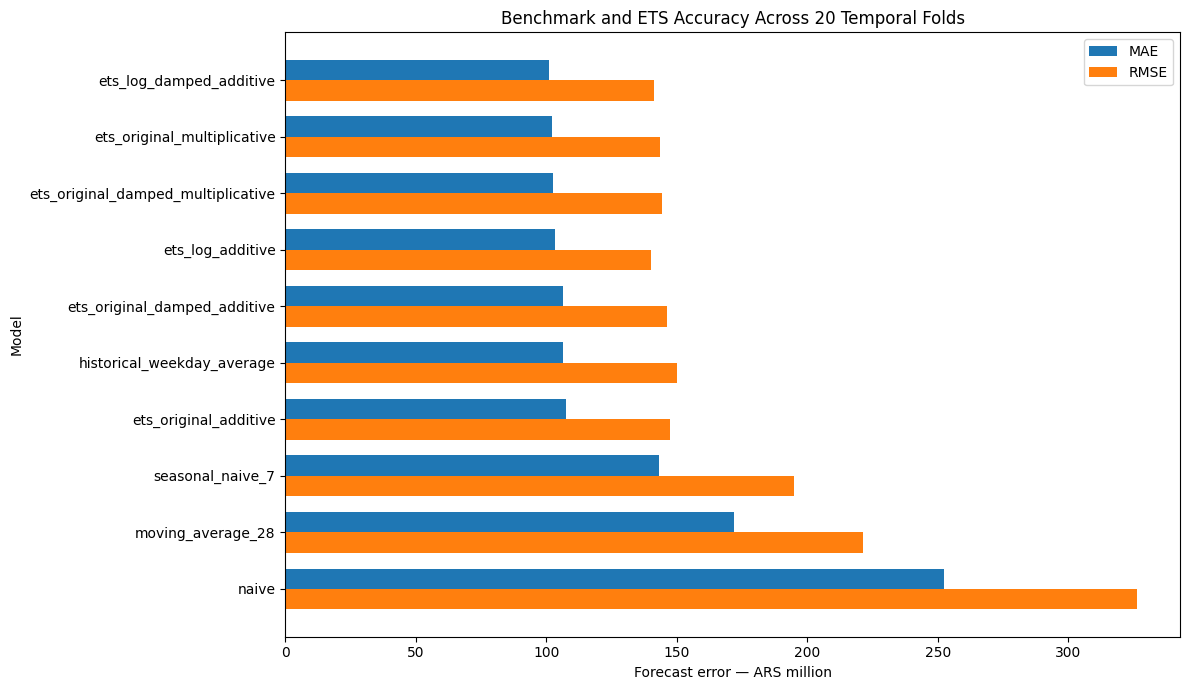

In [39]:
# ---------------------------------------------------------
# Compare all benchmark and ETS models
# ---------------------------------------------------------

all_model_plot_data = (
    all_model_metrics_summary
    .sort_values("mae")
    .reset_index(drop=True)
)

y_positions = np.arange(
    len(all_model_plot_data)
)

bar_height = 0.36

fig, ax = plt.subplots(
    figsize=(12, 7)
)

ax.barh(
    y_positions - bar_height / 2,
    all_model_plot_data["mae"],
    height=bar_height,
    label="MAE",
)

ax.barh(
    y_positions + bar_height / 2,
    all_model_plot_data["rmse"],
    height=bar_height,
    label="RMSE",
)

ax.set_title(
    "Benchmark and ETS Accuracy Across 20 Temporal Folds"
)

ax.set_xlabel(
    "Forecast error — ARS million"
)

ax.set_ylabel("Model")

ax.set_yticks(y_positions)

ax.set_yticklabels(
    all_model_plot_data[
        "model_name"
    ]
)

ax.invert_yaxis()

ax.legend()

fig.tight_layout()

save_figure(
    fig,
    "03_all_model_mae_rmse_comparison.png",
)

plt.show()

### Initial ETS Comparison

ETS models provide measurable predictive value over the strongest benchmark,
although the improvement is moderate rather than overwhelming.

The best model by MAE is `ets_log_damped_additive`:

- MAE: **101.06 ARS million**.
- RMSE: **141.39 ARS million**.
- MAE improvement over Historical Weekday Average: **5.17%**.
- RMSE improvement: **5.70%**.
- Overall bias: approximately **-0.86%**.

The best model by RMSE is `ets_log_additive`:

- MAE: **103.23 ARS million**.
- RMSE: **140.27 ARS million**.
- MAE improvement over Historical Weekday Average: **3.14%**.
- RMSE improvement: **6.45%**.
- Overall bias: approximately **+0.85%**.

The damped logarithmic ETS model is the provisional primary candidate because
it achieves the lowest MAE, maintains low bias, and limits unrestricted
long-term trend extrapolation.

The non-damped logarithmic ETS model remains a secondary candidate because it
achieves the lowest RMSE.

These selections are provisional. Fold-level stability, forecast-horizon
behavior, and residual diagnostics must be reviewed before confirming the ETS
model carried forward.

In [40]:
# ---------------------------------------------------------
# Paired fold-level comparison against the strongest benchmark
# ---------------------------------------------------------

reference_model_name = "historical_weekday_average"

reference_fold_metrics = (
    all_model_metrics_by_fold_raw.loc[
        all_model_metrics_by_fold_raw[
            "model_name"
        ].eq(reference_model_name),
        [
            "fold_id",
            "forecast_origin",
            "mae",
            "rmse",
            "mean_error",
        ],
    ]
    .rename(
        columns={
            "mae": "reference_mae",
            "rmse": "reference_rmse",
            "mean_error": "reference_mean_error",
        }
    )
)

ets_fold_metrics_for_comparison = (
    all_model_metrics_by_fold_raw.loc[
        all_model_metrics_by_fold_raw[
            "model_family"
        ].eq("ets"),
        [
            "fold_id",
            "model_name",
            "forecast_origin",
            "mae",
            "rmse",
            "mean_error",
        ],
    ]
    .rename(
        columns={
            "mae": "model_mae",
            "rmse": "model_rmse",
            "mean_error": "model_mean_error",
        }
    )
)

ets_vs_historical_weekday_by_fold = (
    ets_fold_metrics_for_comparison
    .merge(
        reference_fold_metrics,
        on=[
            "fold_id",
            "forecast_origin",
        ],
        how="left",
        validate="many_to_one",
    )
)

ets_vs_historical_weekday_by_fold[
    "mae_improvement_pct"
] = (
    (
        ets_vs_historical_weekday_by_fold[
            "reference_mae"
        ]
        - ets_vs_historical_weekday_by_fold[
            "model_mae"
        ]
    )
    / ets_vs_historical_weekday_by_fold[
        "reference_mae"
    ]
    * 100
)

ets_vs_historical_weekday_by_fold[
    "rmse_improvement_pct"
] = (
    (
        ets_vs_historical_weekday_by_fold[
            "reference_rmse"
        ]
        - ets_vs_historical_weekday_by_fold[
            "model_rmse"
        ]
    )
    / ets_vs_historical_weekday_by_fold[
        "reference_rmse"
    ]
    * 100
)

ets_vs_historical_weekday_by_fold[
    "mae_better_than_reference"
] = (
    ets_vs_historical_weekday_by_fold[
        "mae_improvement_pct"
    ]
    .gt(0)
    .astype("int8")
)

ets_vs_historical_weekday_by_fold[
    "rmse_better_than_reference"
] = (
    ets_vs_historical_weekday_by_fold[
        "rmse_improvement_pct"
    ]
    .gt(0)
    .astype("int8")
)

ets_vs_historical_weekday_by_fold[
    "both_metrics_better"
] = (
    ets_vs_historical_weekday_by_fold[
        [
            "mae_better_than_reference",
            "rmse_better_than_reference",
        ]
    ]
    .all(axis=1)
    .astype("int8")
)

comparison_numeric_columns = [
    "model_mae",
    "model_rmse",
    "model_mean_error",
    "reference_mae",
    "reference_rmse",
    "reference_mean_error",
    "mae_improvement_pct",
    "rmse_improvement_pct",
]

ets_vs_historical_weekday_by_fold[
    comparison_numeric_columns
] = (
    ets_vs_historical_weekday_by_fold[
        comparison_numeric_columns
    ]
    .round(3)
)

save_table(
    ets_vs_historical_weekday_by_fold,
    "03_ets_vs_historical_weekday_by_fold.csv",
)


# ---------------------------------------------------------
# Summary of paired fold-level differences
# ---------------------------------------------------------

ets_vs_historical_weekday_summary = (
    ets_vs_historical_weekday_by_fold
    .groupby(
        "model_name",
        as_index=False,
    )
    .agg(
        folds_compared=(
            "fold_id",
            "nunique",
        ),
        mae_fold_wins=(
            "mae_better_than_reference",
            "sum",
        ),
        rmse_fold_wins=(
            "rmse_better_than_reference",
            "sum",
        ),
        both_metric_fold_wins=(
            "both_metrics_better",
            "sum",
        ),
        mean_mae_improvement_pct=(
            "mae_improvement_pct",
            "mean",
        ),
        median_mae_improvement_pct=(
            "mae_improvement_pct",
            "median",
        ),
        minimum_mae_improvement_pct=(
            "mae_improvement_pct",
            "min",
        ),
        maximum_mae_improvement_pct=(
            "mae_improvement_pct",
            "max",
        ),
        mean_rmse_improvement_pct=(
            "rmse_improvement_pct",
            "mean",
        ),
        median_rmse_improvement_pct=(
            "rmse_improvement_pct",
            "median",
        ),
        minimum_rmse_improvement_pct=(
            "rmse_improvement_pct",
            "min",
        ),
        maximum_rmse_improvement_pct=(
            "rmse_improvement_pct",
            "max",
        ),
    )
)

summary_percentage_columns = [
    "mean_mae_improvement_pct",
    "median_mae_improvement_pct",
    "minimum_mae_improvement_pct",
    "maximum_mae_improvement_pct",
    "mean_rmse_improvement_pct",
    "median_rmse_improvement_pct",
    "minimum_rmse_improvement_pct",
    "maximum_rmse_improvement_pct",
]

ets_vs_historical_weekday_summary[
    summary_percentage_columns
] = (
    ets_vs_historical_weekday_summary[
        summary_percentage_columns
    ]
    .round(3)
)

ets_vs_historical_weekday_summary = (
    ets_vs_historical_weekday_summary
    .sort_values(
        [
            "mean_mae_improvement_pct",
            "mean_rmse_improvement_pct",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

save_table(
    ets_vs_historical_weekday_summary,
    "03_ets_vs_historical_weekday_summary.csv",
)

ets_vs_historical_weekday_summary

Table saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\03_ets_vs_historical_weekday_by_fold.csv
Table saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\03_ets_vs_historical_weekday_summary.csv


,model_name,folds_compared,mae_fold_wins,rmse_fold_wins,both_metric_fold_wins,mean_mae_improvement_pct,median_mae_improvement_pct,minimum_mae_improvement_pct,maximum_mae_improvement_pct,mean_rmse_improvement_pct,median_rmse_improvement_pct,minimum_rmse_improvement_pct,maximum_rmse_improvement_pct
0,ets_log_damped_additive,20,16,17,15,5.353,4.008,-15.190,25.547,5.934,5.867,-10.323,21.028
1,ets_original_multiplicative,20,15,17,15,4.719,5.150,-12.650,16.149,5.029,5.946,-14.611,19.980
2,ets_original_damped_multiplicative,20,16,16,15,4.488,4.720,-17.680,17.469,4.517,5.984,-18.052,20.192
3,ets_log_additive,20,11,16,11,2.780,1.592,-13.703,30.002,6.069,6.817,-8.813,22.094
4,ets_original_damped_additive,20,14,14,12,-0.659,2.214,-52.992,19.480,1.998,3.456,-30.734,14.712
5,ets_original_additive,20,14,15,13,-1.699,2.029,-62.059,16.247,1.637,3.657,-37.960,14.686


Figure saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\figures\03_top_ets_mae_improvement_by_fold.png


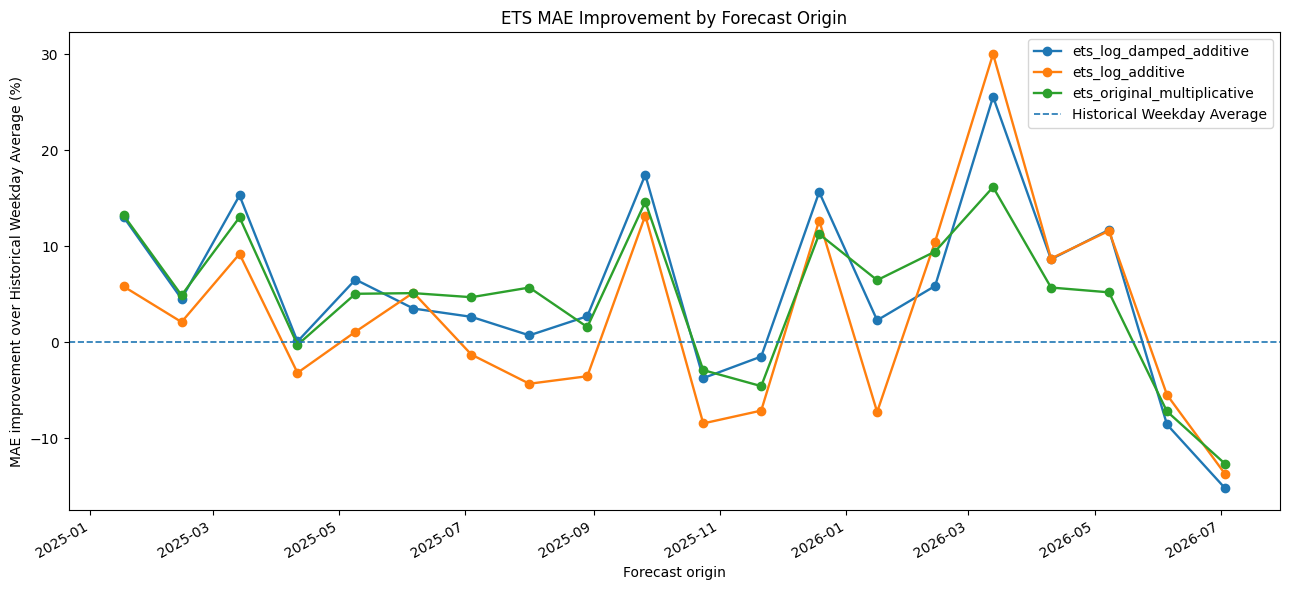

In [41]:
# ---------------------------------------------------------
# Fold-level MAE improvement of the strongest ETS candidates
# ---------------------------------------------------------

top_ets_candidates = [
    "ets_log_damped_additive",
    "ets_log_additive",
    "ets_original_multiplicative",
]

top_ets_fold_comparison = (
    ets_vs_historical_weekday_by_fold.loc[
        ets_vs_historical_weekday_by_fold[
            "model_name"
        ].isin(top_ets_candidates)
    ]
    .sort_values(
        [
            "forecast_origin",
            "model_name",
        ]
    )
)

fig, ax = plt.subplots(
    figsize=(13, 6)
)

for model_name in top_ets_candidates:
    model_data = (
        top_ets_fold_comparison.loc[
            top_ets_fold_comparison[
                "model_name"
            ].eq(model_name)
        ]
        .sort_values("forecast_origin")
    )

    ax.plot(
        model_data["forecast_origin"],
        model_data["mae_improvement_pct"],
        marker="o",
        linewidth=1.7,
        label=model_name,
    )

ax.axhline(
    y=0,
    linewidth=1.2,
    linestyle="--",
    label="Historical Weekday Average",
)

ax.set_title(
    "ETS MAE Improvement by Forecast Origin"
)

ax.set_xlabel("Forecast origin")
ax.set_ylabel(
    "MAE improvement over Historical Weekday Average (%)"
)

ax.legend()
fig.autofmt_xdate()
fig.tight_layout()

save_figure(
    fig,
    "03_top_ets_mae_improvement_by_fold.png",
)

plt.show()

In [43]:
# ---------------------------------------------------------
# Accuracy metrics by forecast horizon for every model
# ---------------------------------------------------------

all_model_metrics_by_horizon = (
    all_model_forecasts
    .groupby(
        [
            "model_family",
            "model_name",
            "forecast_horizon",
        ],
        as_index=False,
    )
    .agg(
        observations=(
            "actual",
            "size",
        ),
        mean_actual=(
            "actual",
            "mean",
        ),
        mean_prediction=(
            "prediction",
            "mean",
        ),
        mae=(
            "absolute_error",
            "mean",
        ),
        mean_squared_error=(
            "squared_error",
            "mean",
        ),
        mean_error=(
            "error",
            "mean",
        ),
    )
)

all_model_metrics_by_horizon["rmse"] = np.sqrt(
    all_model_metrics_by_horizon[
        "mean_squared_error"
    ]
)

all_model_metrics_by_horizon["bias_pct"] = (
    all_model_metrics_by_horizon[
        "mean_error"
    ]
    / all_model_metrics_by_horizon[
        "mean_actual"
    ]
    * 100
)

all_model_metrics_by_horizon = (
    all_model_metrics_by_horizon.drop(
        columns="mean_squared_error"
    )
    .sort_values(
        [
            "model_name",
            "forecast_horizon",
        ]
    )
    .reset_index(drop=True)
)

horizon_numeric_columns = [
    "mean_actual",
    "mean_prediction",
    "mae",
    "mean_error",
    "rmse",
    "bias_pct",
]

all_model_metrics_by_horizon[
    horizon_numeric_columns
] = (
    all_model_metrics_by_horizon[
        horizon_numeric_columns
    ]
    .round(3)
)

save_table(
    all_model_metrics_by_horizon,
    "03_all_model_metrics_by_horizon.csv",
)


selected_horizon_models = [
    "historical_weekday_average",
    "ets_log_damped_additive",
    "ets_log_additive",
    "ets_original_multiplicative",
]

selected_model_metrics_by_horizon = (
    all_model_metrics_by_horizon.loc[
        all_model_metrics_by_horizon[
            "model_name"
        ].isin(selected_horizon_models)
    ]
    .copy()
    .reset_index(drop=True)
)

save_table(
    selected_model_metrics_by_horizon,
    "03_selected_model_metrics_by_horizon.csv",
)

selected_model_metrics_by_horizon.head(12)

Table saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\03_all_model_metrics_by_horizon.csv
Table saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\03_selected_model_metrics_by_horizon.csv


,model_family,model_name,forecast_horizon,observations,mean_actual,mean_prediction,mae,mean_error,rmse,bias_pct
0,ets,ets_log_additive,1,20,740.728,737.539,62.666,-3.189,87.280,-0.431
1,ets,ets_log_additive,2,20,580.138,575.189,29.985,-4.949,42.734,-0.853
2,ets,ets_log_additive,3,20,995.672,998.806,123.916,3.135,151.318,0.315
3,ets,ets_log_additive,4,20,950.133,976.530,124.720,26.397,149.182,2.778
4,ets,ets_log_additive,5,20,971.448,981.548,124.903,10.099,145.274,1.040
5,ets,ets_log_additive,6,20,947.252,982.033,93.097,34.780,117.910,3.672
6,ets,ets_log_additive,7,20,1087.910,1081.630,133.963,-6.280,171.378,-0.577
7,ets,ets_log_additive,8,20,726.126,743.280,56.738,17.155,68.572,2.363
8,ets,ets_log_additive,9,20,566.140,579.667,52.653,13.527,72.677,2.389
9,ets,ets_log_additive,10,20,1034.126,1006.580,137.040,-27.547,207.000,-2.664


Figure saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\figures\03_selected_models_mae_by_horizon.png


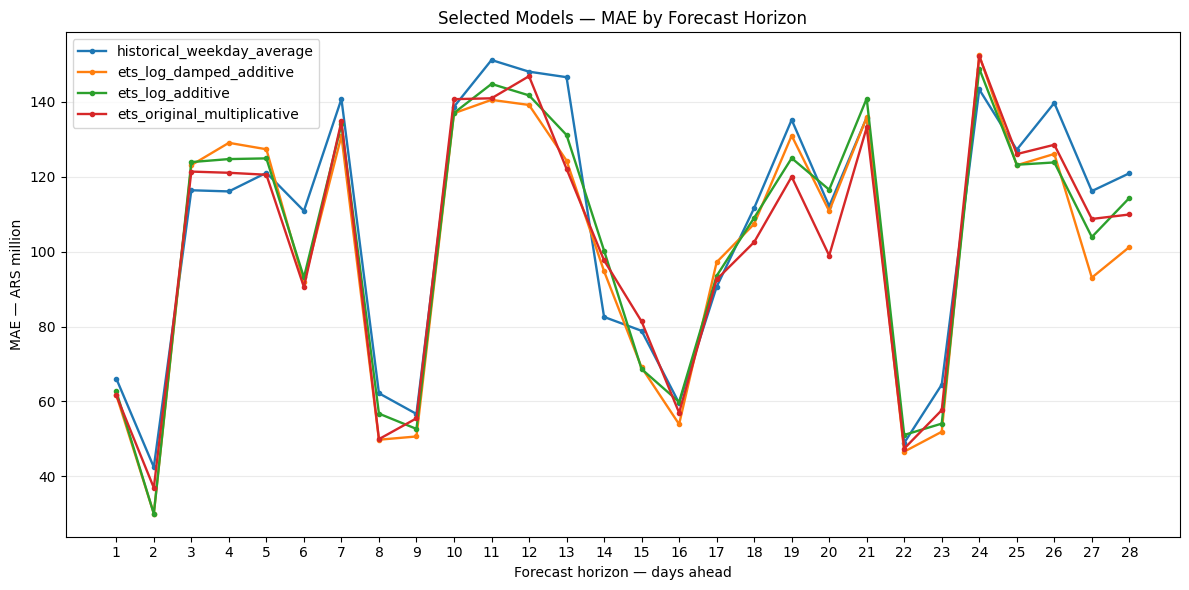

In [44]:
# ---------------------------------------------------------
# Horizon-level comparison of the selected models
# ---------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(12, 6)
)

for model_name in selected_horizon_models:
    model_data = (
        selected_model_metrics_by_horizon.loc[
            selected_model_metrics_by_horizon[
                "model_name"
            ].eq(model_name)
        ]
        .sort_values("forecast_horizon")
    )

    ax.plot(
        model_data["forecast_horizon"],
        model_data["mae"],
        marker="o",
        markersize=3,
        linewidth=1.7,
        label=model_name,
    )

ax.set_title(
    "Selected Models — MAE by Forecast Horizon"
)

ax.set_xlabel("Forecast horizon — days ahead")
ax.set_ylabel("MAE — ARS million")

ax.set_xticks(
    range(
        1,
        FORECAST_HORIZON + 1,
    )
)

ax.grid(
    axis="y",
    alpha=0.25,
)

ax.legend()

fig.tight_layout()

save_figure(
    fig,
    "03_selected_models_mae_by_horizon.png",
)

plt.show()

### Fold and Horizon Stability Findings

The paired fold-level comparison confirms
`ets_log_damped_additive` as the primary ETS candidate.

Compared with the Historical Weekday Average:

- It achieves lower MAE in **16 of 20 folds**.
- It achieves lower RMSE in **17 of 20 folds**.
- It improves both metrics simultaneously in **15 folds**.
- Its mean fold-level MAE improvement is **5.35%**.
- Its median fold-level MAE improvement is **4.01%**.
- Its mean fold-level RMSE improvement is **5.93%**.

The improvement is not universal. In its least favorable fold, MAE deteriorates
by approximately 15.2%. The final forecast origins also show weaker performance
than the Historical Weekday Average.

The horizon-level comparison shows that all weekly seasonal models retain a
similar periodic error structure. No single model dominates every day of the
28-day horizon.

`ets_log_damped_additive` is therefore selected as the primary ETS model,
while `ets_log_additive` remains the secondary ETS candidate because it
achieves the lowest overall RMSE.

The Historical Weekday Average will remain an active reference model and may
later be evaluated as part of a forecast combination.

## Out-of-Sample Error Diagnostics

The primary ETS candidate is evaluated using its 560 genuinely out-of-sample
forecast errors from the common temporal backtest.

The signed forecast error is defined as:

$$
e_{t+h}
=
\hat{y}_{t+h}
-
y_{t+h}
$$

Therefore:

- Positive errors indicate over-forecasting.
- Negative errors indicate under-forecasting.

Because the selected ETS model was fitted on the logarithmic scale, the
analysis also considers:

$$
e^{(\log)}_{t+h}
=
\log(\hat{y}_{t+h})
-
\log(y_{t+h})
$$

Original-scale errors are used for business interpretation. Logarithmic errors
are used for statistical residual diagnostics because their variance is less
dependent on the cash-outflow level.

The pooled errors come from repeated 28-day forecasts. Their diagnostics are
therefore interpreted as out-of-sample forecast-error diagnostics rather than
as pure one-step-ahead model residuals.

In [45]:
# ---------------------------------------------------------
# Selected models
# ---------------------------------------------------------

PRIMARY_ETS_MODEL = "ets_log_damped_additive"
SECONDARY_ETS_MODEL = "ets_log_additive"
REFERENCE_BENCHMARK = "historical_weekday_average"


# ---------------------------------------------------------
# Store the model-selection decision
# ---------------------------------------------------------

primary_global_metrics = (
    all_model_metrics_summary.loc[
        all_model_metrics_summary[
            "model_name"
        ].eq(PRIMARY_ETS_MODEL)
    ]
    .iloc[0]
)

secondary_global_metrics = (
    all_model_metrics_summary.loc[
        all_model_metrics_summary[
            "model_name"
        ].eq(SECONDARY_ETS_MODEL)
    ]
    .iloc[0]
)

primary_paired_metrics = (
    ets_vs_historical_weekday_summary.loc[
        ets_vs_historical_weekday_summary[
            "model_name"
        ].eq(PRIMARY_ETS_MODEL)
    ]
    .iloc[0]
)

secondary_paired_metrics = (
    ets_vs_historical_weekday_summary.loc[
        ets_vs_historical_weekday_summary[
            "model_name"
        ].eq(SECONDARY_ETS_MODEL)
    ]
    .iloc[0]
)

model_selection_decision = pd.DataFrame(
    [
        {
            "role": "primary_ets",
            "model_name": PRIMARY_ETS_MODEL,
            "mae": primary_global_metrics["mae"],
            "rmse": primary_global_metrics["rmse"],
            "bias_pct": primary_global_metrics["bias_pct"],
            "mae_fold_wins_vs_reference": (
                primary_paired_metrics["mae_fold_wins"]
            ),
            "rmse_fold_wins_vs_reference": (
                primary_paired_metrics["rmse_fold_wins"]
            ),
            "selection_reason": (
                "Lowest overall MAE, low bias, positive "
                "median fold-level improvement, and damped trend."
            ),
        },
        {
            "role": "secondary_ets",
            "model_name": SECONDARY_ETS_MODEL,
            "mae": secondary_global_metrics["mae"],
            "rmse": secondary_global_metrics["rmse"],
            "bias_pct": secondary_global_metrics["bias_pct"],
            "mae_fold_wins_vs_reference": (
                secondary_paired_metrics["mae_fold_wins"]
            ),
            "rmse_fold_wins_vs_reference": (
                secondary_paired_metrics["rmse_fold_wins"]
            ),
            "selection_reason": (
                "Lowest overall RMSE and low global bias."
            ),
        },
        {
            "role": "reference_benchmark",
            "model_name": REFERENCE_BENCHMARK,
            "mae": historical_reference_mae,
            "rmse": historical_reference_rmse,
            "bias_pct": (
                all_model_metrics_summary.loc[
                    all_model_metrics_summary[
                        "model_name"
                    ].eq(REFERENCE_BENCHMARK),
                    "bias_pct",
                ]
                .iloc[0]
            ),
            "mae_fold_wins_vs_reference": np.nan,
            "rmse_fold_wins_vs_reference": np.nan,
            "selection_reason": (
                "Strongest simple benchmark and useful operational challenger."
            ),
        },
    ]
)

save_table(
    model_selection_decision,
    "03_model_selection_decision.csv",
)

display(model_selection_decision)


# ---------------------------------------------------------
# Extract the primary ETS out-of-sample forecasts
# ---------------------------------------------------------

selected_ets_oos_forecasts = (
    ets_backtest_forecasts.loc[
        ets_backtest_forecasts[
            "model_name"
        ].eq(PRIMARY_ETS_MODEL)
    ]
    .copy()
    .sort_values("target_date")
    .reset_index(drop=True)
)

selected_ets_oos_forecasts[
    "log_actual"
] = np.log(
    selected_ets_oos_forecasts["actual"]
)

selected_ets_oos_forecasts[
    "log_prediction"
] = np.log(
    selected_ets_oos_forecasts["prediction"]
)

selected_ets_oos_forecasts[
    "log_error"
] = (
    selected_ets_oos_forecasts["log_prediction"]
    - selected_ets_oos_forecasts["log_actual"]
)

selected_ets_oos_forecasts[
    "absolute_percentage_error"
] = (
    selected_ets_oos_forecasts["absolute_error"]
    / selected_ets_oos_forecasts["actual"]
    * 100
)

assert len(selected_ets_oos_forecasts) == (
    len(backtest_folds)
    * FORECAST_HORIZON
), (
    "The selected ETS forecast table has an incorrect number of rows."
)

assert (
    selected_ets_oos_forecasts[
        "target_date"
    ]
    .duplicated()
    .sum()
    == 0
), (
    "Duplicated target dates were detected."
)

assert selected_ets_oos_forecasts.isna().sum().sum() == 0, (
    "Missing selected-model forecast values were detected."
)

save_table(
    selected_ets_oos_forecasts,
    "03_selected_ets_oos_forecasts.csv",
)

selected_ets_oos_forecasts.head()

Table saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\03_model_selection_decision.csv


,role,model_name,mae,rmse,bias_pct,mae_fold_wins_vs_reference,rmse_fold_wins_vs_reference,selection_reason
0,primary_ets,ets_log_damped_additive,101.062000,141.389000,-0.862,16.0,17.0,"Lowest overall MAE, low bias, positive median ..."
1,secondary_ets,ets_log_additive,103.226000,140.270000,0.849,11.0,16.0,Lowest overall RMSE and low global bias.
2,reference_benchmark,historical_weekday_average,106.576212,149.940772,-3.802,NaN,NaN,Strongest simple benchmark and useful operatio...


Table saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\03_selected_ets_oos_forecasts.csv


,fold_id,model_name,forecast_origin,target_date,forecast_horizon,actual,prediction,error,absolute_error,squared_error,mase_scale,rmsse_scale,absolute_scaled_error,squared_scaled_error,log_actual,log_prediction,log_error,absolute_percentage_error
0,fold_01,ets_log_damped_additive,2025-01-17,2025-01-18,1,692.977,596.103426,-96.873574,96.873574,9384.489261,80.748053,12306.372514,1.199702,0.762572,6.540997,6.390414,-0.150583,13.979335
1,fold_01,ets_log_damped_additive,2025-01-17,2025-01-19,2,468.426,465.704074,-2.721926,2.721926,7.408882,80.748053,12306.372514,0.033709,0.000602,6.149378,6.143550,-0.005828,0.581079
2,fold_01,ets_log_damped_additive,2025-01-17,2025-01-20,3,774.585,796.874721,22.289721,22.289721,496.831649,80.748053,12306.372514,0.276040,0.040372,6.652327,6.680697,0.028370,2.877634
3,fold_01,ets_log_damped_additive,2025-01-17,2025-01-21,4,758.083,787.426903,29.343903,29.343903,861.064628,80.748053,12306.372514,0.363401,0.069969,6.630793,6.668771,0.037978,3.870803
4,fold_01,ets_log_damped_additive,2025-01-17,2025-01-22,5,721.854,781.235861,59.381861,59.381861,3526.205367,80.748053,12306.372514,0.735397,0.286535,6.581823,6.660877,0.079054,8.226298


In [46]:
# ---------------------------------------------------------
# Out-of-sample error summary
# ---------------------------------------------------------

oos_errors = (
    selected_ets_oos_forecasts["error"]
)

oos_log_errors = (
    selected_ets_oos_forecasts["log_error"]
)

selected_ets_oos_error_summary = pd.Series(
    {
        "model_name": PRIMARY_ETS_MODEL,

        "number_of_forecasts": len(
            selected_ets_oos_forecasts
        ),

        "number_of_folds": (
            selected_ets_oos_forecasts[
                "fold_id"
            ].nunique()
        ),

        "first_target_date": (
            selected_ets_oos_forecasts[
                "target_date"
            ].min()
        ),

        "last_target_date": (
            selected_ets_oos_forecasts[
                "target_date"
            ].max()
        ),

        "mean_actual": round(
            selected_ets_oos_forecasts[
                "actual"
            ].mean(),
            3,
        ),

        "mean_prediction": round(
            selected_ets_oos_forecasts[
                "prediction"
            ].mean(),
            3,
        ),

        "mean_error": round(
            oos_errors.mean(),
            3,
        ),

        "bias_pct": round(
            oos_errors.mean()
            / selected_ets_oos_forecasts[
                "actual"
            ].mean()
            * 100,
            3,
        ),

        "mae": round(
            selected_ets_oos_forecasts[
                "absolute_error"
            ].mean(),
            3,
        ),

        "rmse": round(
            np.sqrt(
                selected_ets_oos_forecasts[
                    "squared_error"
                ].mean()
            ),
            3,
        ),

        "median_absolute_error": round(
            selected_ets_oos_forecasts[
                "absolute_error"
            ].median(),
            3,
        ),

        "mean_absolute_percentage_error": round(
            selected_ets_oos_forecasts[
                "absolute_percentage_error"
            ].mean(),
            3,
        ),

        "error_standard_deviation": round(
            oos_errors.std(),
            3,
        ),

        "error_p01": round(
            oos_errors.quantile(0.01),
            3,
        ),

        "error_p05": round(
            oos_errors.quantile(0.05),
            3,
        ),

        "error_median": round(
            oos_errors.median(),
            3,
        ),

        "error_p95": round(
            oos_errors.quantile(0.95),
            3,
        ),

        "error_p99": round(
            oos_errors.quantile(0.99),
            3,
        ),

        "overforecast_share": round(
            oos_errors.gt(0).mean(),
            3,
        ),

        "underforecast_share": round(
            oos_errors.lt(0).mean(),
            3,
        ),

        "mean_log_error": round(
            oos_log_errors.mean(),
            5,
        ),

        "log_error_standard_deviation": round(
            oos_log_errors.std(),
            5,
        ),
    },
    name="value",
).rename_axis("statistic").reset_index()

save_table(
    selected_ets_oos_error_summary,
    "03_selected_ets_oos_error_summary.csv",
)

selected_ets_oos_error_summary

Table saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\03_selected_ets_oos_error_summary.csv


,statistic,value
0,model_name,ets_log_damped_additive
1,number_of_forecasts,560
2,number_of_folds,20
3,first_target_date,2025-01-18 00:00:00
4,last_target_date,2026-07-31 00:00:00
5,mean_actual,907.671
6,mean_prediction,899.846
7,mean_error,-7.826
8,bias_pct,-0.862
9,mae,101.062


In [47]:
from statsmodels.stats.diagnostic import (
    acorr_ljungbox,
    het_arch,
)
from statsmodels.stats.stattools import (
    jarque_bera,
)


# ---------------------------------------------------------
# Ljung-Box test on out-of-sample log errors
# ---------------------------------------------------------

ljung_box_lags = [
    7,
    14,
    28,
    56,
]

selected_ets_oos_ljung_box = (
    acorr_ljungbox(
        oos_log_errors,
        lags=ljung_box_lags,
        return_df=True,
    )
    .reset_index()
    .rename(
        columns={
            "index": "lag",
            "lb_stat": "ljung_box_statistic",
            "lb_pvalue": "p_value",
        }
    )
)

selected_ets_oos_ljung_box[
    "significant_autocorrelation"
] = (
    selected_ets_oos_ljung_box[
        "p_value"
    ]
    .lt(0.05)
)

save_table(
    selected_ets_oos_ljung_box,
    "03_selected_ets_oos_ljung_box.csv",
)


# ---------------------------------------------------------
# Distribution and conditional-variance diagnostics
# ---------------------------------------------------------

(
    jb_statistic,
    jb_p_value,
    residual_skewness,
    residual_kurtosis,
) = jarque_bera(oos_log_errors)

(
    arch_lm_statistic,
    arch_lm_p_value,
    arch_f_statistic,
    arch_f_p_value,
) = het_arch(
    oos_log_errors,
    nlags=7,
)

selected_ets_oos_statistical_diagnostics = pd.DataFrame(
    [
        {
            "diagnostic": "jarque_bera_normality",
            "statistic": jb_statistic,
            "p_value": jb_p_value,
            "null_hypothesis": (
                "Log forecast errors are normally distributed."
            ),
            "reject_null_at_5pct": (
                jb_p_value < 0.05
            ),
        },
        {
            "diagnostic": "arch_lm_7_lags",
            "statistic": arch_lm_statistic,
            "p_value": arch_lm_p_value,
            "null_hypothesis": (
                "No ARCH-type conditional heteroscedasticity "
                "is present through lag 7."
            ),
            "reject_null_at_5pct": (
                arch_lm_p_value < 0.05
            ),
        },
    ]
)

selected_ets_oos_statistical_diagnostics[
    "statistic"
] = (
    selected_ets_oos_statistical_diagnostics[
        "statistic"
    ]
    .round(4)
)

selected_ets_oos_statistical_diagnostics[
    "p_value"
] = (
    selected_ets_oos_statistical_diagnostics[
        "p_value"
    ]
    .round(6)
)

save_table(
    selected_ets_oos_statistical_diagnostics,
    "03_selected_ets_oos_statistical_diagnostics.csv",
)

display(selected_ets_oos_ljung_box)
display(selected_ets_oos_statistical_diagnostics)

print(
    f"Log-error skewness: {residual_skewness:.4f}"
)

print(
    f"Log-error kurtosis: {residual_kurtosis:.4f}"
)

print(
    f"ARCH F-test p-value: {arch_f_p_value:.6f}"
)

Table saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\03_selected_ets_oos_ljung_box.csv
Table saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\03_selected_ets_oos_statistical_diagnostics.csv


,lag,ljung_box_statistic,p_value,significant_autocorrelation
0,7,119.956391,7.823138e-23,True
1,14,145.096683,6.855019e-24,True
2,28,243.099949,3.695776e-36,True
3,56,370.210272,7.264189e-48,True


,diagnostic,statistic,p_value,null_hypothesis,reject_null_at_5pct
0,jarque_bera_normality,50.3778,0.000000,Log forecast errors are normally distributed.,True
1,arch_lm_7_lags,19.5703,0.006576,No ARCH-type conditional heteroscedasticity is...,True


Log-error skewness: -0.3737
Log-error kurtosis: 4.2651
ARCH F-test p-value: 0.006192


Figure saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\figures\03_selected_ets_oos_errors_over_time.png


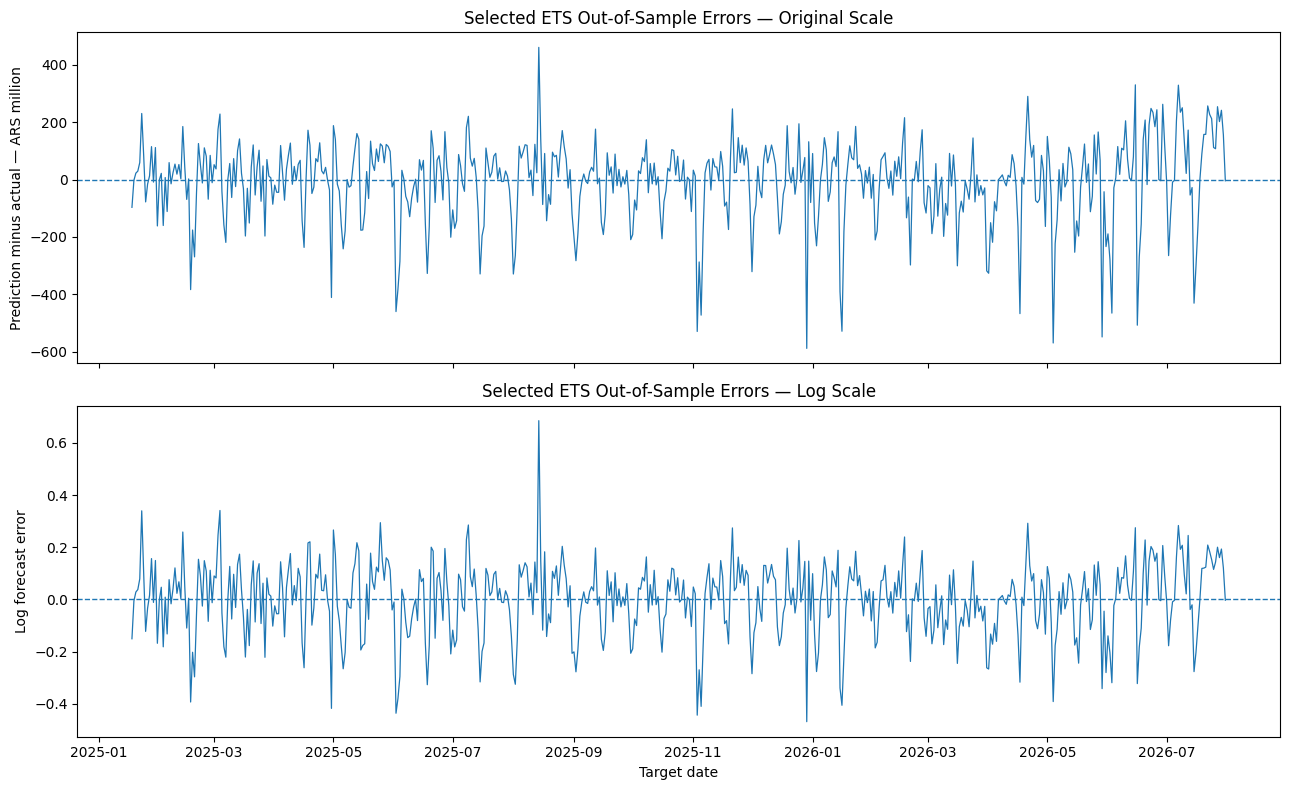

In [48]:
# ---------------------------------------------------------
# Out-of-sample forecast errors over time
# ---------------------------------------------------------

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(13, 8),
    sharex=True,
)

axes[0].plot(
    selected_ets_oos_forecasts[
        "target_date"
    ],
    selected_ets_oos_forecasts[
        "error"
    ],
    linewidth=0.9,
)

axes[0].axhline(
    y=0,
    linewidth=1,
    linestyle="--",
)

axes[0].set_title(
    "Selected ETS Out-of-Sample Errors — Original Scale"
)

axes[0].set_ylabel(
    "Prediction minus actual — ARS million"
)

axes[1].plot(
    selected_ets_oos_forecasts[
        "target_date"
    ],
    selected_ets_oos_forecasts[
        "log_error"
    ],
    linewidth=0.9,
)

axes[1].axhline(
    y=0,
    linewidth=1,
    linestyle="--",
)

axes[1].set_title(
    "Selected ETS Out-of-Sample Errors — Log Scale"
)

axes[1].set_xlabel("Target date")
axes[1].set_ylabel("Log forecast error")

fig.tight_layout()

save_figure(
    fig,
    "03_selected_ets_oos_errors_over_time.png",
)

plt.show()

Figure saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\figures\03_selected_ets_oos_log_error_acf.png


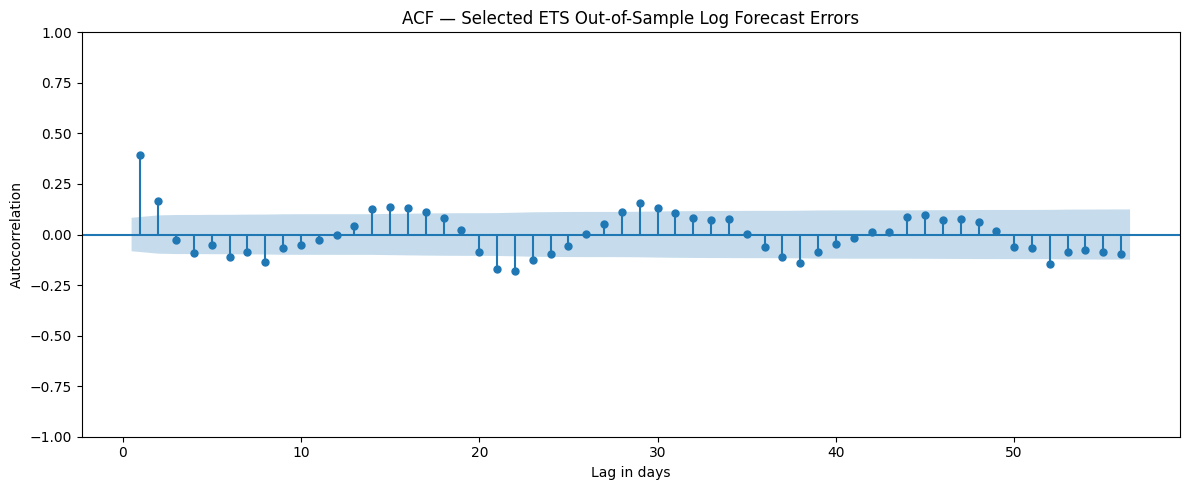

In [49]:
from statsmodels.graphics.tsaplots import (
    plot_acf,
)

fig, ax = plt.subplots(
    figsize=(12, 5)
)

plot_acf(
    oos_log_errors,
    lags=56,
    zero=False,
    ax=ax,
)

ax.set_title(
    "ACF — Selected ETS Out-of-Sample Log Forecast Errors"
)

ax.set_xlabel("Lag in days")
ax.set_ylabel("Autocorrelation")

fig.tight_layout()

save_figure(
    fig,
    "03_selected_ets_oos_log_error_acf.png",
)

plt.show()

Figure saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\figures\03_selected_ets_oos_log_error_distribution.png


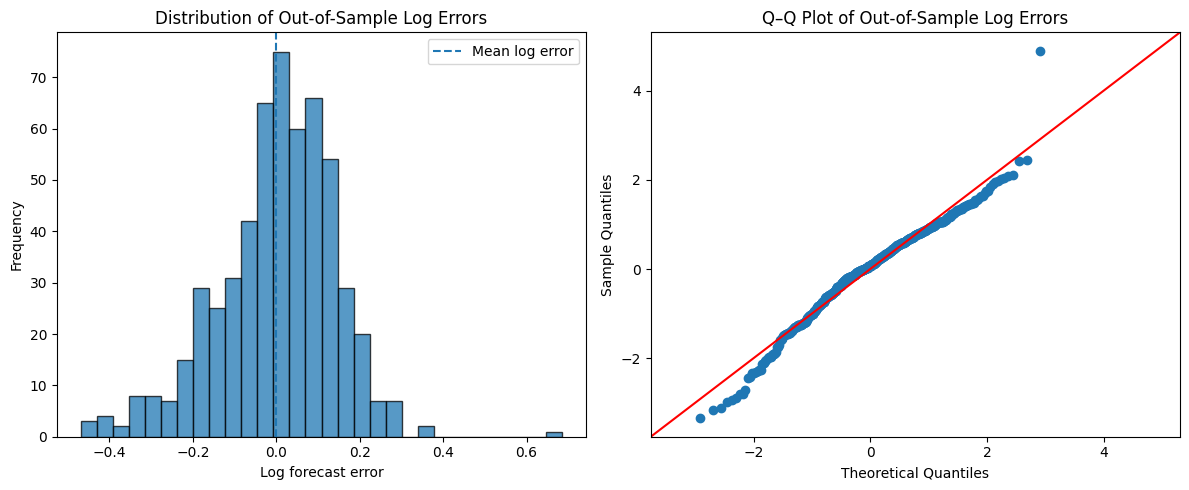

In [50]:
from statsmodels.graphics.gofplots import (
    qqplot,
)

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 5),
)

axes[0].hist(
    oos_log_errors,
    bins=30,
    edgecolor="black",
    alpha=0.75,
)

axes[0].axvline(
    oos_log_errors.mean(),
    linewidth=1.5,
    linestyle="--",
    label="Mean log error",
)

axes[0].set_title(
    "Distribution of Out-of-Sample Log Errors"
)

axes[0].set_xlabel("Log forecast error")
axes[0].set_ylabel("Frequency")
axes[0].legend()

qqplot(
    oos_log_errors,
    line="45",
    fit=True,
    ax=axes[1],
)

axes[1].set_title(
    "Q–Q Plot of Out-of-Sample Log Errors"
)

fig.tight_layout()

save_figure(
    fig,
    "03_selected_ets_oos_log_error_distribution.png",
)

plt.show()

### Out-of-Sample Error Findings

The selected ETS model maintains low aggregate bias and competitive point
forecast accuracy:

- MAE: **101.06 ARS million**.
- RMSE: **141.39 ARS million**.
- Mean absolute percentage error: **10.66%**.
- Overall percentage bias: **-0.86%**.
- Mean logarithmic error: **0.00026**.

The error diagnostics nevertheless identify several limitations:

- Ljung–Box tests reject the absence of autocorrelation at lags 7, 14, 28,
  and 56.
- The Jarque–Bera test rejects normality.
- Log errors show slight negative skewness and excess kurtosis.
- The ARCH-LM test detects time-varying conditional variance.

The pooled sequence contains multi-step errors from repeated 28-day forecast
paths. Errors belonging to the same forecast origin are not expected to be
independent, so the pooled Ljung–Box result is not interpreted as a formal
one-step residual whiteness test.

The findings nevertheless indicate that Gaussian, independent, and
homoscedastic ETS errors would be an inadequate basis for the final
probabilistic intervals.

Later probabilistic forecasts should therefore be calibrated using
out-of-sample errors, with explicit attention to forecast horizon and
time-varying uncertainty.

In [51]:
# ---------------------------------------------------------
# Add calendar and event context to out-of-sample forecasts
# ---------------------------------------------------------

diagnostic_context_columns = [
    DATE_COLUMN,
    "day_name",
    "is_weekend",
    "is_payday_window",
    "is_month_end",
    "is_holiday",
    "is_promotion",
    "system_incident",
    "is_large_merchant_settlement",
    "is_macro_shock",
]

selected_ets_oos_context = (
    selected_ets_oos_forecasts
    .merge(
        df[diagnostic_context_columns],
        left_on="target_date",
        right_on=DATE_COLUMN,
        how="left",
        validate="one_to_one",
    )
    .drop(columns=DATE_COLUMN)
)

assert len(selected_ets_oos_context) == len(
    selected_ets_oos_forecasts
), (
    "The contextual merge changed the number of forecasts."
)

assert selected_ets_oos_context.isna().sum().sum() == 0, (
    "Missing values were introduced during the contextual merge."
)


# ---------------------------------------------------------
# Define business-condition masks
# ---------------------------------------------------------

no_extraordinary_event = (
    selected_ets_oos_context["is_promotion"].eq(0)
    & selected_ets_oos_context["system_incident"].eq(0)
    & selected_ets_oos_context[
        "is_large_merchant_settlement"
    ].eq(0)
    & selected_ets_oos_context["is_macro_shock"].eq(0)
)

condition_masks = {
    "all_days": pd.Series(
        True,
        index=selected_ets_oos_context.index,
    ),

    "weekday": (
        selected_ets_oos_context["is_weekend"].eq(0)
    ),

    "weekend": (
        selected_ets_oos_context["is_weekend"].eq(1)
    ),

    "payday_window": (
        selected_ets_oos_context[
            "is_payday_window"
        ].eq(1)
    ),

    "non_payday_window": (
        selected_ets_oos_context[
            "is_payday_window"
        ].eq(0)
    ),

    "month_end": (
        selected_ets_oos_context["is_month_end"].eq(1)
    ),

    "holiday": (
        selected_ets_oos_context["is_holiday"].eq(1)
    ),

    "promotion": (
        selected_ets_oos_context["is_promotion"].eq(1)
    ),

    "system_incident": (
        selected_ets_oos_context[
            "system_incident"
        ].eq(1)
    ),

    "merchant_settlement": (
        selected_ets_oos_context[
            "is_large_merchant_settlement"
        ].eq(1)
    ),

    "macro_shock": (
        selected_ets_oos_context[
            "is_macro_shock"
        ].eq(1)
    ),

    "no_extraordinary_event": (
        no_extraordinary_event
    ),
}


def summarize_oos_condition(
    condition_name,
    condition_mask,
):
    """
    Summarize out-of-sample performance for one business condition.
    """
    condition_data = (
        selected_ets_oos_context.loc[
            condition_mask
        ]
        .copy()
    )

    if condition_data.empty:
        return {
            "condition": condition_name,
            "observations": 0,
            "mean_actual": np.nan,
            "mean_prediction": np.nan,
            "mae": np.nan,
            "rmse": np.nan,
            "mean_error": np.nan,
            "median_error": np.nan,
            "bias_pct": np.nan,
            "mean_log_error": np.nan,
            "overforecast_share": np.nan,
            "underforecast_share": np.nan,
        }

    return {
        "condition": condition_name,

        "observations": len(condition_data),

        "mean_actual": (
            condition_data["actual"].mean()
        ),

        "mean_prediction": (
            condition_data["prediction"].mean()
        ),

        "mae": (
            condition_data["absolute_error"].mean()
        ),

        "rmse": np.sqrt(
            condition_data["squared_error"].mean()
        ),

        "mean_error": (
            condition_data["error"].mean()
        ),

        "median_error": (
            condition_data["error"].median()
        ),

        "bias_pct": (
            condition_data["error"].mean()
            / condition_data["actual"].mean()
            * 100
        ),

        "mean_log_error": (
            condition_data["log_error"].mean()
        ),

        "overforecast_share": (
            condition_data["error"].gt(0).mean()
        ),

        "underforecast_share": (
            condition_data["error"].lt(0).mean()
        ),
    }


selected_ets_oos_error_by_condition = pd.DataFrame(
    [
        summarize_oos_condition(
            condition_name,
            condition_mask,
        )
        for condition_name, condition_mask
        in condition_masks.items()
    ]
)

condition_numeric_columns = [
    "mean_actual",
    "mean_prediction",
    "mae",
    "rmse",
    "mean_error",
    "median_error",
    "bias_pct",
    "mean_log_error",
    "overforecast_share",
    "underforecast_share",
]

selected_ets_oos_error_by_condition[
    condition_numeric_columns
] = (
    selected_ets_oos_error_by_condition[
        condition_numeric_columns
    ]
    .round(3)
)

save_table(
    selected_ets_oos_error_by_condition,
    "03_selected_ets_oos_error_by_condition.csv",
)


# ---------------------------------------------------------
# Validation checks
# ---------------------------------------------------------

selected_ets_oos_condition_checks = pd.Series(
    {
        "forecast_rows_after_merge": len(
            selected_ets_oos_context
        ),

        "expected_forecast_rows": (
            len(backtest_folds)
            * FORECAST_HORIZON
        ),

        "missing_context_values": int(
            selected_ets_oos_context
            .isna()
            .sum()
            .sum()
        ),

        "duplicated_target_dates": int(
            selected_ets_oos_context[
                "target_date"
            ]
            .duplicated()
            .sum()
        ),

        "conditions_summarized": len(
            selected_ets_oos_error_by_condition
        ),

        "conditions_without_observations": int(
            selected_ets_oos_error_by_condition[
                "observations"
            ]
            .eq(0)
            .sum()
        ),
    },
    name="value",
).rename_axis("check").reset_index()

save_table(
    selected_ets_oos_condition_checks,
    "03_selected_ets_oos_condition_checks.csv",
)

display(selected_ets_oos_condition_checks)
display(selected_ets_oos_error_by_condition)

Table saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\03_selected_ets_oos_error_by_condition.csv
Table saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\03_selected_ets_oos_condition_checks.csv


,check,value
0,forecast_rows_after_merge,560
1,expected_forecast_rows,560
2,missing_context_values,0
3,duplicated_target_dates,0
4,conditions_summarized,12
5,conditions_without_observations,0


,condition,observations,mean_actual,mean_prediction,mae,rmse,mean_error,median_error,bias_pct,mean_log_error,overforecast_share,underforecast_share
0,all_days,560,907.671,899.846,101.062,141.389,-7.826,7.839,-0.862,0.000,0.539,0.461
1,weekday,400,1008.943,998.313,120.805,161.137,-10.630,15.449,-1.054,-0.001,0.542,0.458
2,weekend,160,654.493,653.678,51.703,71.102,-0.814,4.001,-0.124,0.004,0.531,0.469
3,payday_window,108,1158.480,962.784,195.826,232.393,-195.697,-172.094,-16.893,-0.181,0.009,0.991
4,non_payday_window,452,847.744,884.807,78.419,108.919,37.064,32.876,4.372,0.044,0.666,0.334
5,month_end,19,1026.773,899.093,140.158,172.020,-127.680,-116.682,-12.435,-0.139,0.053,0.947
6,holiday,32,840.532,965.363,150.703,166.290,124.831,142.401,14.851,0.150,0.875,0.125
7,promotion,16,1189.238,998.896,199.461,255.165,-190.341,-156.266,-16.005,-0.165,0.062,0.938
8,system_incident,3,630.784,957.791,327.007,341.287,327.007,289.938,51.841,0.439,1.000,0.000
9,merchant_settlement,3,1558.407,1042.190,516.217,521.784,-516.217,-548.789,-33.125,-0.409,0.000,1.000


Figure saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\figures\03_selected_ets_oos_bias_by_condition.png


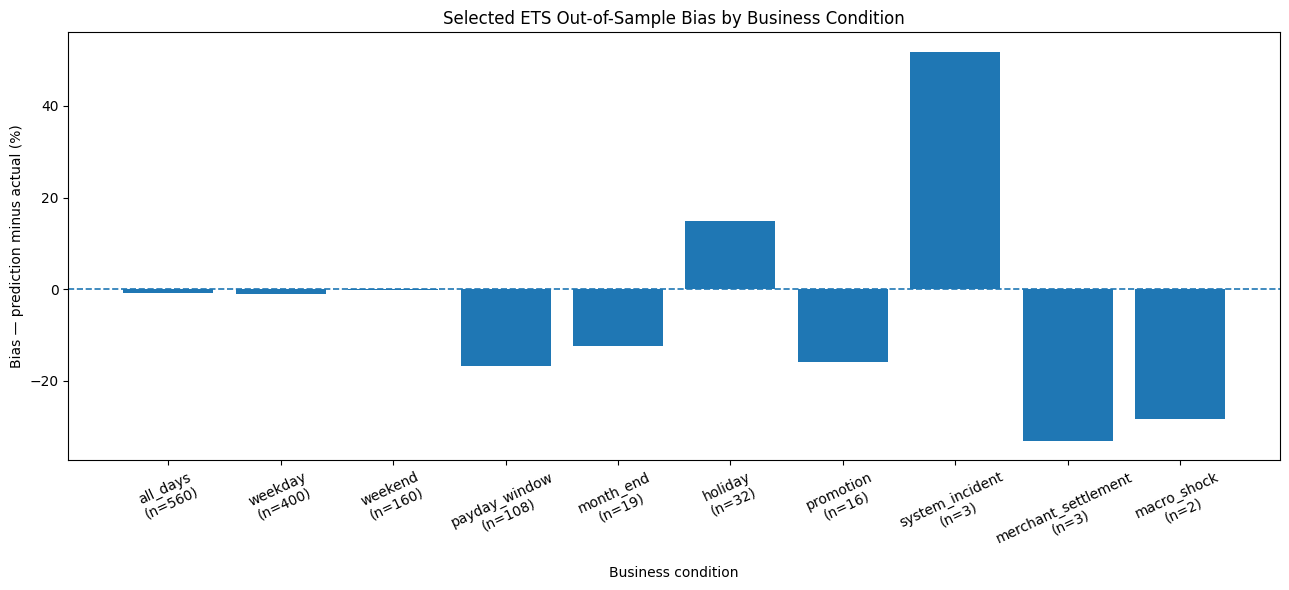

In [52]:
# ---------------------------------------------------------
# Business-condition bias visualization
# ---------------------------------------------------------

conditions_for_plot = [
    "all_days",
    "weekday",
    "weekend",
    "payday_window",
    "month_end",
    "holiday",
    "promotion",
    "system_incident",
    "merchant_settlement",
    "macro_shock",
]

condition_plot_data = (
    selected_ets_oos_error_by_condition
    .set_index("condition")
    .loc[conditions_for_plot]
    .reset_index()
)

condition_plot_labels = [
    (
        f"{row.condition}\n"
        f"(n={int(row.observations)})"
    )
    for row in condition_plot_data.itertuples(
        index=False
    )
]

fig, ax = plt.subplots(
    figsize=(13, 6)
)

ax.bar(
    condition_plot_labels,
    condition_plot_data["bias_pct"],
)

ax.axhline(
    y=0,
    linewidth=1.2,
    linestyle="--",
)

ax.set_title(
    "Selected ETS Out-of-Sample Bias by Business Condition"
)

ax.set_xlabel("Business condition")
ax.set_ylabel(
    "Bias — prediction minus actual (%)"
)

ax.tick_params(
    axis="x",
    rotation=25,
)

fig.tight_layout()

save_figure(
    fig,
    "03_selected_ets_oos_bias_by_condition.png",
)

plt.show()

### Business-Condition Error Findings

The selected ETS model performs well on average but exhibits important
condition-dependent forecast bias.

On days without extraordinary events, its aggregate bias is effectively zero.
However, the low global bias hides substantial errors that offset one another
across business conditions.

The most relevant findings are:

- Payday-window cash outflows are underestimated by approximately **16.9%**
  across 108 observations.
- Month-end cash outflows are underestimated by approximately **12.4%**.
- Promotional dates are underestimated by approximately **16.0%**.
- Holidays are overestimated by approximately **14.9%**.
- All observed merchant-settlement and macro-shock dates are substantially
  underestimated.

The rare-event estimates must be interpreted cautiously:

- System incidents contain 3 observations.
- Merchant settlements contain 3 observations.
- Macroeconomic shocks contain 2 observations.

Their directions are informative, but their estimated magnitudes are not
precise population effects.

The selected ETS model captures level, trend, and weekly seasonality, but it
does not explicitly observe future calendar and event conditions. Therefore,
it remains a strong unconditional statistical benchmark but is not considered
sufficient as a standalone operational liquidity model.

Notebook 04 will evaluate dynamic regression and SARIMAX specifications that
explicitly incorporate valid calendar and exogenous information.

In [53]:
# ---------------------------------------------------------
# Operational interpretation of the selected ETS model
# ---------------------------------------------------------

selected_ets_operational_assessment = pd.DataFrame(
    [
        {
            "assessment": "point_forecast_accuracy",
            "finding": (
                "The selected ETS improves MAE by 5.17% and RMSE by "
                "5.70% relative to the strongest simple benchmark."
            ),
            "status": "validated",
        },
        {
            "assessment": "aggregate_bias",
            "finding": (
                "Overall bias is low at approximately -0.86%, "
                "but this value hides offsetting conditional errors."
            ),
            "status": "caution",
        },
        {
            "assessment": "regular_days",
            "finding": (
                "Bias on days without extraordinary events is "
                "approximately zero."
            ),
            "status": "validated",
        },
        {
            "assessment": "payday_window",
            "finding": (
                "Cash outflows are underestimated by approximately "
                "16.9% across 108 payday-window observations."
            ),
            "status": "material_risk",
        },
        {
            "assessment": "promotions",
            "finding": (
                "Promotional dates are underestimated by approximately "
                "16.0% across 16 observations."
            ),
            "status": "material_risk",
        },
        {
            "assessment": "rare_high_outflow_events",
            "finding": (
                "Merchant settlements and macro shocks are strongly "
                "underestimated, but their sample sizes are very small."
            ),
            "status": "descriptive_risk",
        },
        {
            "assessment": "probabilistic_assumptions",
            "finding": (
                "Out-of-sample errors are autocorrelated, non-normal, "
                "and heteroscedastic."
            ),
            "status": "invalid_simple_gaussian_intervals",
        },
        {
            "assessment": "model_role",
            "finding": (
                "Retain ETS as an unconditional statistical benchmark, "
                "not as the standalone operational liquidity model."
            ),
            "status": "active",
        },
        {
            "assessment": "next_modeling_step",
            "finding": (
                "Evaluate dynamic regression and SARIMAX with valid "
                "calendar and exogenous variables."
            ),
            "status": "notebook_04",
        },
    ]
)

save_table(
    selected_ets_operational_assessment,
    "03_selected_ets_operational_assessment.csv",
)

selected_ets_operational_assessment

Table saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\03_selected_ets_operational_assessment.csv


,assessment,finding,status
0,point_forecast_accuracy,The selected ETS improves MAE by 5.17% and RMS...,validated
1,aggregate_bias,"Overall bias is low at approximately -0.86%, b...",caution
2,regular_days,Bias on days without extraordinary events is a...,validated
3,payday_window,Cash outflows are underestimated by approximat...,material_risk
4,promotions,Promotional dates are underestimated by approx...,material_risk
5,rare_high_outflow_events,Merchant settlements and macro shocks are stro...,descriptive_risk
6,probabilistic_assumptions,"Out-of-sample errors are autocorrelated, non-n...",invalid_simple_gaussian_intervals
7,model_role,Retain ETS as an unconditional statistical ben...,active
8,next_modeling_step,Evaluate dynamic regression and SARIMAX with v...,notebook_04
